In [ ]:
eri - mldl - final project - 08 - 2025

Source: https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024/

This is a dataset showing information on CyberSecurity attacks, and threads from 2015-2024. 10 countries are covered. It is noteworthy that Ukraine isn't on the list as it has been attacked many times recently by Russia. NATO also has a specific Cybersecurity taskforce with Estonia (also not mentioned) being a primary contributor. Attacks specifically by Russia on other nations would also generally be a topic of interest.

Explanations: 

-----------------------------------------------------------
Attack Type

DoSo - Distributed Denial of Service - Basically overwhelm the servers of a website, or network with too many requests at once. Often a network of 'zombie' computers with a type of malware installed on them will be involved, unknown to the users of these devices. The same result can also happen accidently, like with people knowing a sale will be on a certain website at a certain time, and too many users overloading the servers by all wanting something at once.1
Phishi - Scam websites or emails that seek to gain sensitive information by pretending to be others.29
SQL Inject - Specific to data driven applications. These insert a malicious line of code that carries out an action such as sending all that information to the hacker. It can also be used to alter or destroy all the data in the system. - We should be very aware of these sorts of attacks!503
Ransom - Malicious software that makes a user's data or system inoperable or encrypted as to be inaccessible until an amount is paid to the attackers.  493
Ma - Malicious software, computer viruses of various types. intentionally designed to cause harm or disruption to systems, clients, networks or servers or to leak sensitive information ect.  485
Man-in-the- - Attacker recieves information by being 'in between' two sources. For example someone's emails are being routed through an unknown 3rd party, or unsecured websites without knowledge of the other parties.   459
-----------------------------------------------------------
Security Vulnerabilit
y Type
Z - A hole or exploit in the software that the developers and those who could stop it are unaware of.    785
Social Eng - Psychological influence (tho not direct manipulation) of persons within the targeted organization.g    747
Unpatched - Software where a zero-day or other vulnerability was fixed, but that has not been updated.re    738
Weak        730
-----------------------------------------------------------
Defense Mechanism Used - Methods used to prevent an attack

Antivirus - Software that scans for 'viruses' or software that is flagged as potentially harmful in some way to the computer or network. 
VPN  - Stands for Virtual Private Network - This encrypts the user's internet connection, and disguises the user's identity online.
Encryption - This means that the data has been made into a cypher that needs to be decrypted or translated to be understood.
Firewall - a security system that protects the network, not the individual computer.
AI-based Detection - Like an anti-virus but more advanced detection cap
-----------------------------------------------------------abilities.

In [872]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn import metrics
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, BayesianRidge
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from ydata_profiling import ProfileReport
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [46]:
cyber=pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")

In [69]:
cyber.head(5)

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [50]:
cyber.tail(5)

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9
2999,Germany,2021,SQL Injection,Retail,48.20,480984,Unknown,Zero-day,VPN,64


In [876]:
cyber.shape

(3000, 10)

In [54]:
cyber.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,3000.0,2019.570333,2.857932,2015.0,2017.0000,2020.000,2022.00,2024.00
Financial Loss (in Million $),3000.0,50.492970,28.791415,0.5,25.7575,50.795,75.63,99.99
Number of Affected Users,3000.0,504684.136333,289944.084972,424.0,255805.2500,504513.000,758088.50,999635.00
Incident Resolution Time (in Hours),3000.0,36.476000,20.570768,1.0,19.0000,37.000,55.00,72.00


In [174]:
cyber.duplicated().sum()

0

In [177]:
cyber.isna().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [56]:
cyber.value_counts()

Country    Year  Attack Type    Target Industry     Financial Loss (in Million $)  Number of Affected Users  Attack Source  Security Vulnerability Type  Defense Mechanism Used  Incident Resolution Time (in Hours)
Australia  2015  DDoS           Education           51.54                          297721                    Nation-state   Weak Passwords               Antivirus               29                                     1
Japan      2022  DDoS           Retail              64.38                          88354                     Nation-state   Social Engineering           AI-based Detection      52                                     1
           2021  SQL Injection  Retail              64.81                          263770                    Unknown        Social Engineering           Antivirus               62                                     1
                                                    82.52                          214372                    Insider        Unpatched

In [60]:
def info(df):
    df_info= pd.concat([df.dtypes, df.isna().sum(),df.nunique()], axis=1, keys=['Data types','Number of missing values', 'Number of unique values'])
    return(df_info)

In [62]:
info(cyber)

,Data types,Number of missing values,Number of unique values
Country,object,0,10
Year,int64,0,10
Attack Type,object,0,6
Target Industry,object,0,7
Financial Loss (in Million $),float64,0,2536
Number of Affected Users,int64,0,2998
Attack Source,object,0,4
Security Vulnerability Type,object,0,4
Defense Mechanism Used,object,0,5
Incident Resolution Time (in Hours),int64,0,72


In [ ]:
#In this case Incident Resolution or Financial Loss could both be good Regression Targets. I am going to go with 
# Incident Resolution Time, in part because the target industries vary too much in how much money they could lose.

In [249]:
stats.normaltest(cyber["Financial Loss (in Million $)"])

NormaltestResult(statistic=2729.211321020291, pvalue=0.0)

In [251]:
stats.normaltest(cyber["Number of Affected Users"])

NormaltestResult(statistic=2571.45410685362, pvalue=0.0)

In [253]:
stats.normaltest(cyber["Incident Resolution Time (in Hours)"])

NormaltestResult(statistic=2334.1474728887183, pvalue=0.0)

In [ ]:
#Not Normal Data.

In [71]:
cyber.value_counts("Country")

Country
UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64

(array([281., 308., 321., 291., 305., 297., 295., 310., 305., 287.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

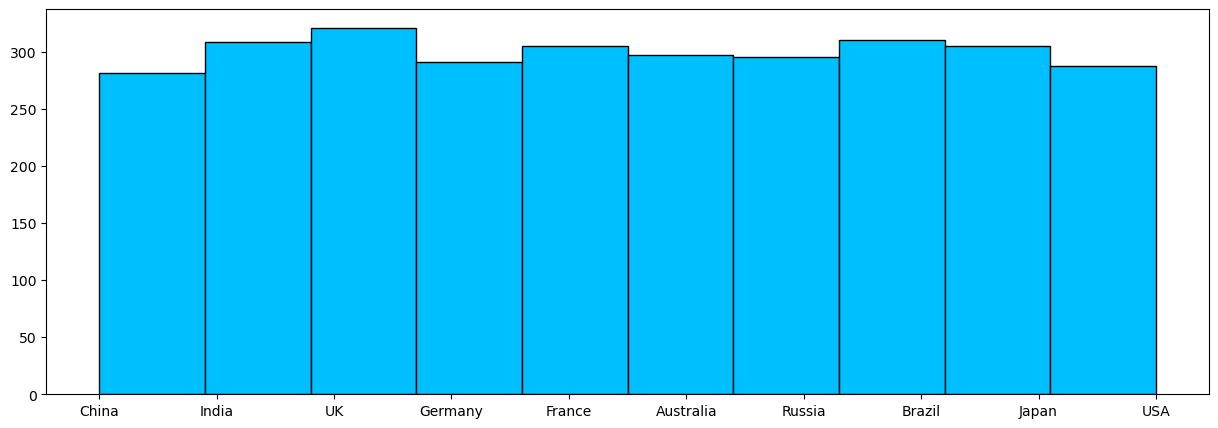

In [878]:
plt.rcParams["figure.figsize"] = (15,5)
plt.hist(cyber['Country'], edgecolor="black", color="deepskyblue")

In [73]:
cyber.value_counts("Attack Type")

Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64

(array([529.,   0., 493.,   0., 459.,   0., 531.,   0., 503., 485.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

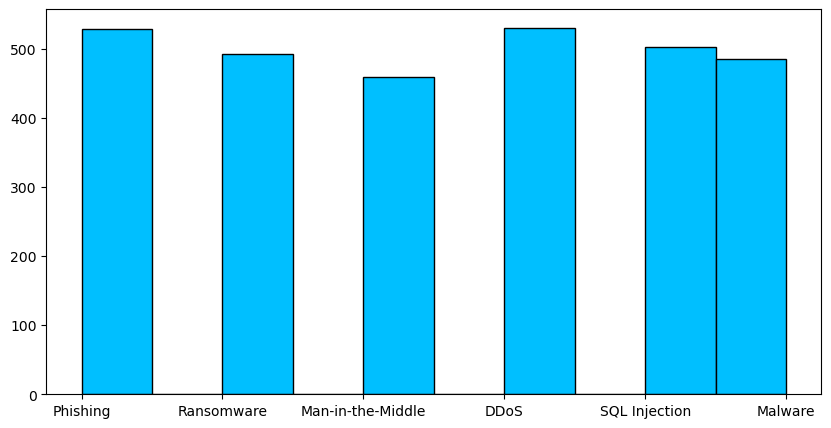

In [880]:
plt.rcParams["figure.figsize"] = (10,5)
plt.hist(cyber['Attack Type'], edgecolor="black", color="deepskyblue")

In [75]:
cyber.value_counts("Target Industry")

Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Government            403
Telecommunications    403
Name: count, dtype: int64

(array([419., 423.,   0., 478.,   0., 403., 403.,   0., 445., 429.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

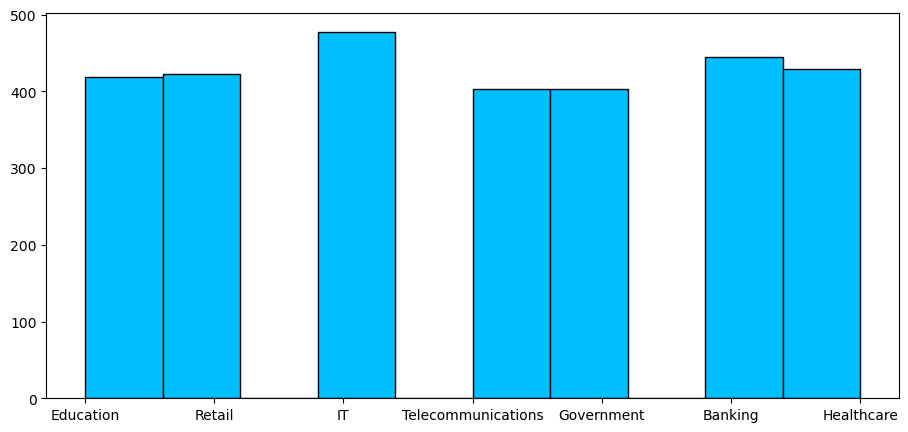

In [906]:
plt.rcParams["figure.figsize"] = (11,5)
plt.hist(cyber['Target Industry'], edgecolor="black", color="deepskyblue")

In [77]:
cyber.value_counts("Attack Source")

Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64

(array([686.,   0.,   0., 794.,   0.,   0., 752.,   0.,   0., 768.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

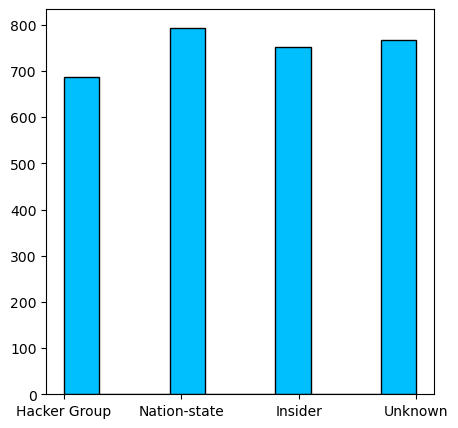

In [884]:
plt.rcParams["figure.figsize"] = (5,5)
plt.hist(cyber['Attack Source'],edgecolor="black", color="deepskyblue")

In [79]:
cyber.value_counts("Security Vulnerability Type")

Security Vulnerability Type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: count, dtype: int64

(array([738.,   0.,   0., 730.,   0.,   0., 747.,   0.,   0., 785.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

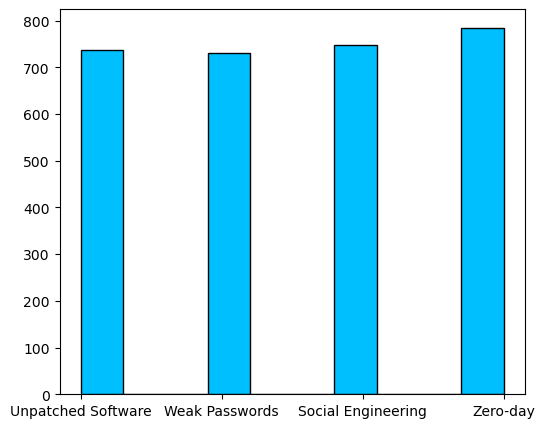

In [888]:
plt.rcParams["figure.figsize"] = (6,5)
plt.hist(cyber['Security Vulnerability Type'], edgecolor="black", color="deepskyblue")

In [81]:
cyber.value_counts("Defense Mechanism Used")

Defense Mechanism Used
Antivirus             628
VPN                   612
Encryption            592
Firewall              585
AI-based Detection    583
Name: count, dtype: int64

(array([612.,   0., 585.,   0.,   0., 583.,   0., 628.,   0., 592.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

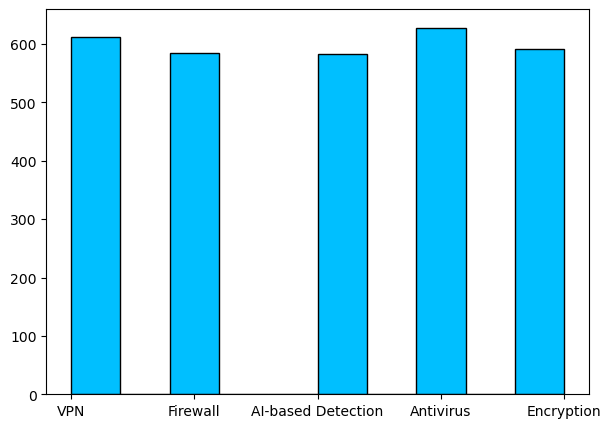

In [892]:
plt.rcParams["figure.figsize"] = (7,5)
plt.hist(cyber['Defense Mechanism Used'], edgecolor="black", color="deepskyblue")

In [184]:
cyber.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [ ]:
#Year could also be considered Categorical.

(array([277., 285., 319., 310., 263., 315., 299., 318., 315., 299.]),
 array([2015. , 2015.9, 2016.8, 2017.7, 2018.6, 2019.5, 2020.4, 2021.3,
        2022.2, 2023.1, 2024. ]),
 <BarContainer object of 10 artists>)

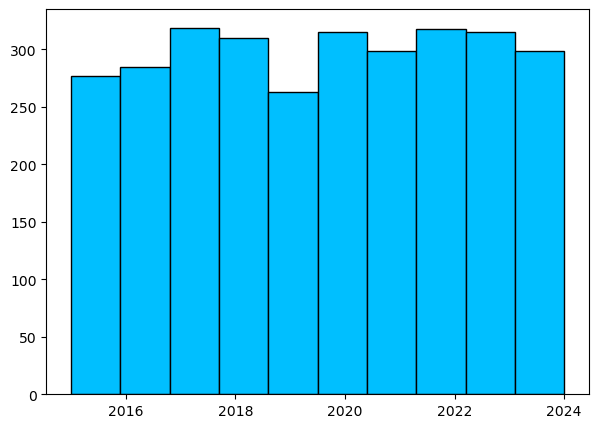

In [894]:
plt.hist(cyber['Year'], edgecolor="black", color="deepskyblue")

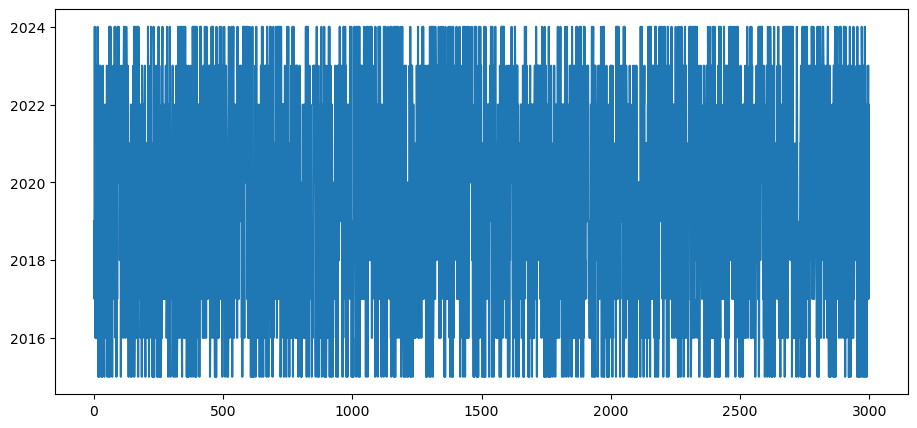

In [216]:
plt.plot(cyber['Year'])

(array([288., 327., 266., 311., 295., 299., 291., 314., 322., 287.]),
 array([ 0.5  , 10.449, 20.398, 30.347, 40.296, 50.245, 60.194, 70.143,
        80.092, 90.041, 99.99 ]),
 <BarContainer object of 10 artists>)

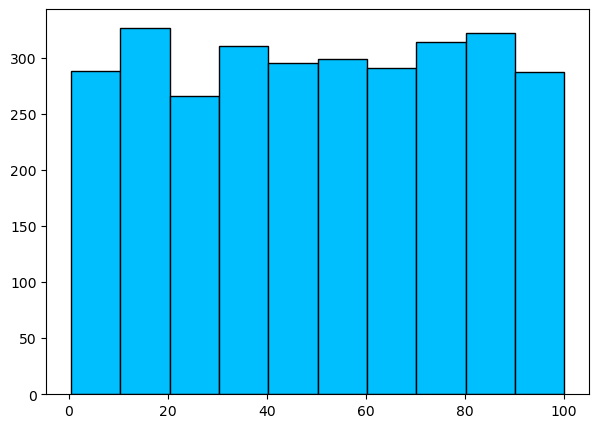

In [896]:
plt.hist(cyber['Financial Loss (in Million $)'], edgecolor="black", color="deepskyblue")
settitle

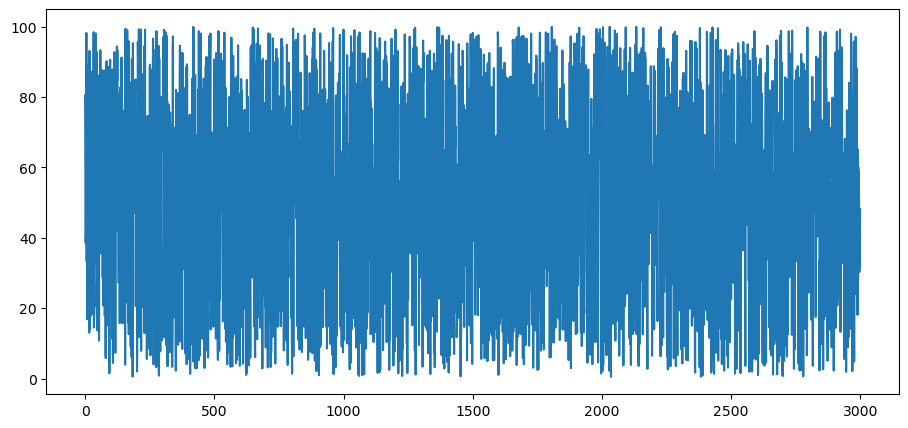

In [218]:
plt.plot(cyber['Financial Loss (in Million $)'])

(array([315., 297., 308., 293., 286., 310., 273., 310., 289., 319.]),
 array([ 1. ,  8.1, 15.2, 22.3, 29.4, 36.5, 43.6, 50.7, 57.8, 64.9, 72. ]),
 <BarContainer object of 10 artists>)

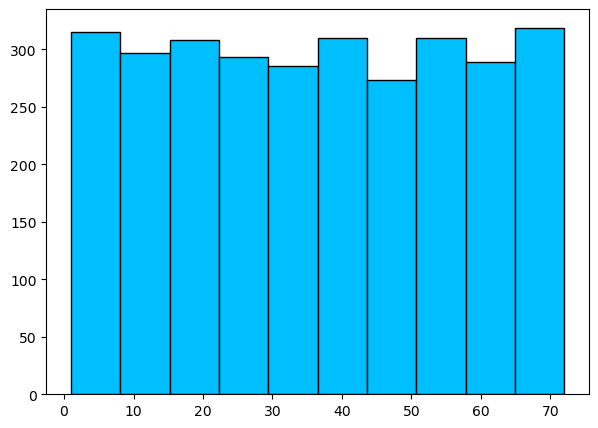

In [898]:
plt.hist(cyber['Incident Resolution Time (in Hours)'], edgecolor="black", color="deepskyblue")

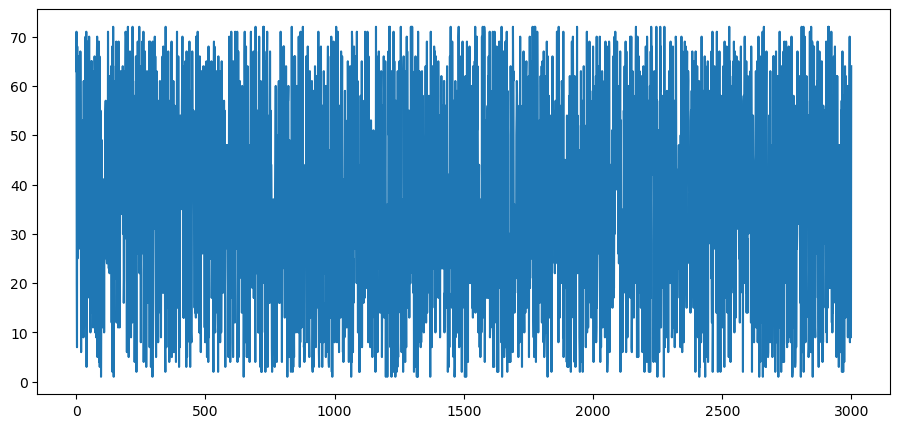

In [220]:
plt.plot(cyber['Incident Resolution Time (in Hours)'])

(array([314., 282., 288., 301., 302., 292., 298., 293., 326., 304.]),
 array([4.240000e+02, 1.003451e+05, 2.002662e+05, 3.001873e+05,
        4.001084e+05, 5.000295e+05, 5.999506e+05, 6.998717e+05,
        7.997928e+05, 8.997139e+05, 9.996350e+05]),
 <BarContainer object of 10 artists>)

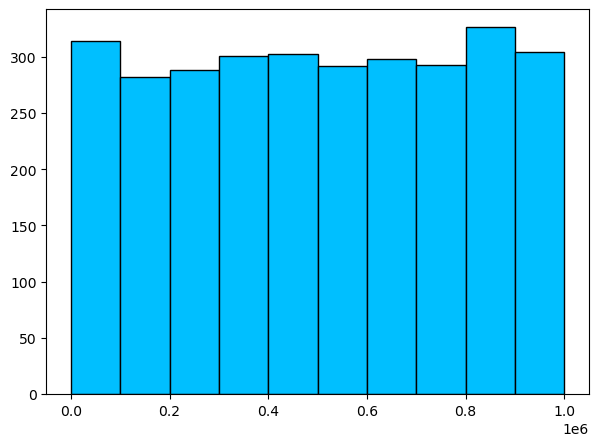

In [900]:
plt.hist(cyber['Number of Affected Users'], edgecolor="black", color="deepskyblue")

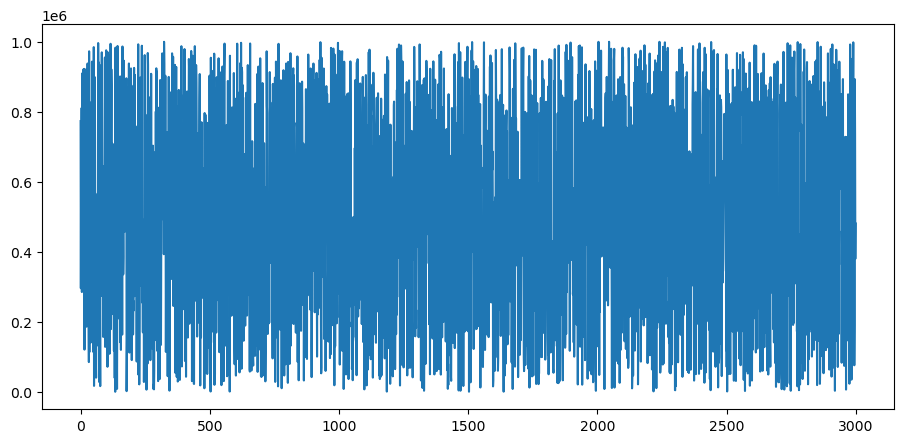

In [222]:
plt.plot(cyber['Number of Affected Users'])

In [225]:
def outliers(col):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    UIF=Q3+1.5*(IQR)
    LIF=Q1-1.5*(IQR)
    df_out =df[(df[col]<LIF) | (df[col]>UIF)]
    sns.distplot(df_out[col])
   
    return df_out[col] .describe()

In [229]:
cyber.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [233]:
df=cyber

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Financial Loss (in Million $), dtype: float64

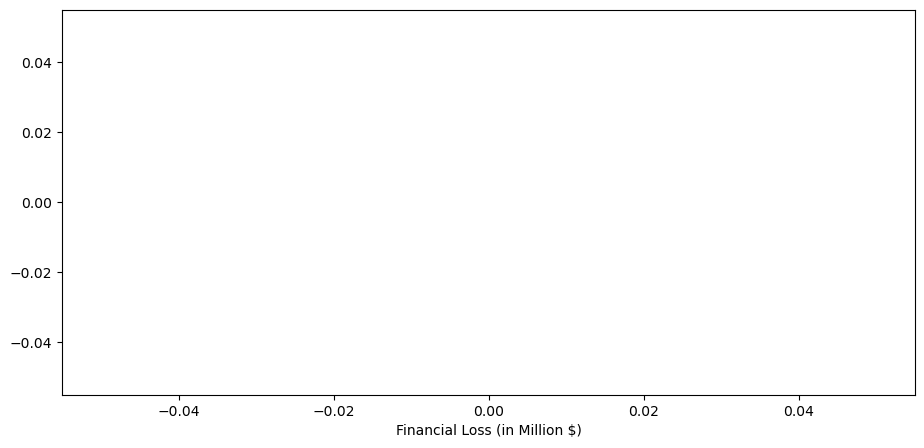

In [243]:
outliers("Financial Loss (in Million $)")

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Number of Affected Users, dtype: float64

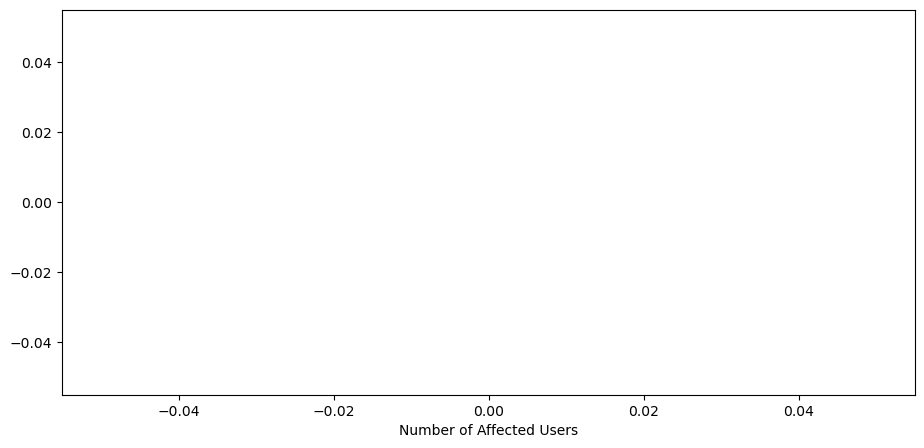

In [247]:
outliers("Number of Affected Users")

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Incident Resolution Time (in Hours), dtype: float64

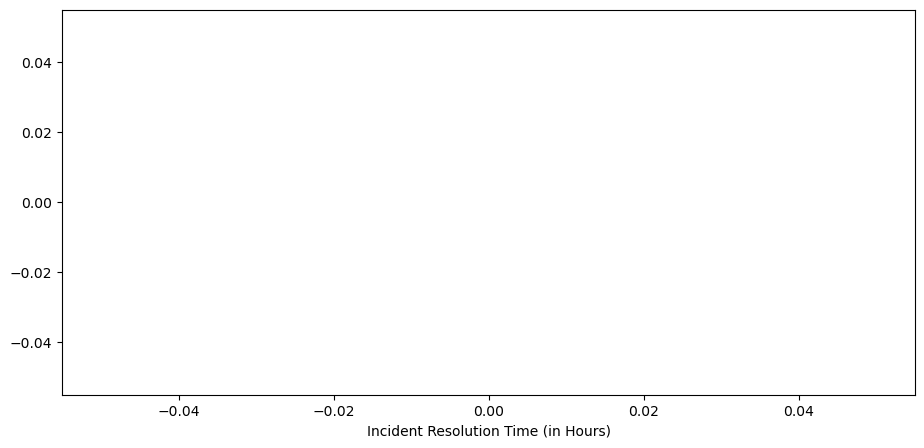

In [235]:
outliers("Incident Resolution Time (in Hours)")

In [ ]:
#No outliers. But the Data isn't 'normal' as in it is not a bell curve. It is evenly distributed.

In [257]:
from scipy.stats import chi2_contingency
def chi_square(c1,c2):
    chi_2, p_val, dof, exp_val = chi2_contingency(pd.crosstab(df[c1],df[c2],margins = False))# make sure margins = False
    print("Actual values:\n")
    print(pd.crosstab(df[c1],df[c2],margins = False))
    print("="*100)
    print("Expected values: \n")
    print(exp_val)
    print("="*100)
    #print('\nChi-square is : %f'%chi_2, '\n\np_value is : %f'%p_val, '\n\ndegree of freedom is : %i'%dof)
    print(f'\nChi-square is : {chi_2}', f'\n\np_value is : {p_val}', f'\n\ndegree of freedom is :{dof}')
    print("="*100)
    if exp_val.min()<5 or np.sum(exp_val)<50 : print("\n********************************************\nWarning :We have some small expected \
values or the total number of observations is not enough to get any conclusion\n******************************************** ")
        #Note for sum of all values in dataframe use df.values.sum() and for numpy.ndarray use np.sum(arr)
    elif p_val < 0.05:# consider significan level is 5%
        print(F"\nThere is statistiacally significant correlation between {c1} and {c2} at 0.05 significant level")
    else:
        print(F"\nThere is no correlation between the two variables( we don't have enough evidence to conclude there is a a statistically significant relationship between {c1} and {c2}")

In [259]:
cyber.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [281]:
chi_square("Country","Attack Type")

Actual values:

Country            Australia  Brazil  China  France  Germany  India  Japan  \
Attack Type                                                                  
DDoS                      61      61     48      50       43     50     49   
Malware                   61      51     44      47       45     47     49   
Man-in-the-Middle         45      44     44      38       49     46     55   
Phishing                  51      54     49      64       46     51     57   
Ransomware                40      43     51      51       46     59     41   
SQL Injection             39      57     45      55       62     55     54   

Country            Russia  UK  USA  
Attack Type                         
DDoS                   54  55   60  
Malware                46  53   42  
Man-in-the-Middle      49  49   40  
Phishing               39  64   54  
Ransomware             58  51   53  
SQL Injection          49  49   38  
Expected values: 

[[52.569      54.87       49.737      53.985

<Axes: xlabel='Country', ylabel='count'>

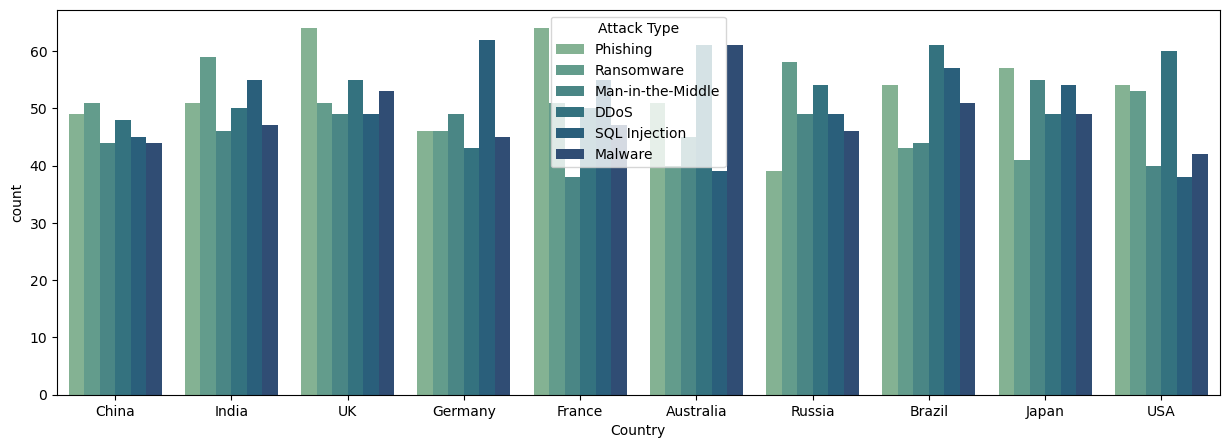

In [425]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Country"],hue =cyber["Attack Type"],palette="crest")

In [303]:
chi_square("Country","Target Industry")

Actual values:

Target Industry  Banking  Education  Government  Healthcare  IT  Retail  \
Country                                                                   
Australia             47         40          38          51  37      41   
Brazil                47         47          36          50  50      44   
China                 36         47          34          41  47      37   
France                41         41          46          54  50      46   
Germany               45         30          45          42  45      40   
India                 46         42          44          40  53      44   
Japan                 40         50          35          41  50      47   
Russia                48         46          39          40  44      26   
UK                    55         36          45          37  55      46   
USA                   40         40          41          33  47      52   

Target Industry  Telecommunications  
Country                              
Austral

<Axes: xlabel='Country', ylabel='count'>

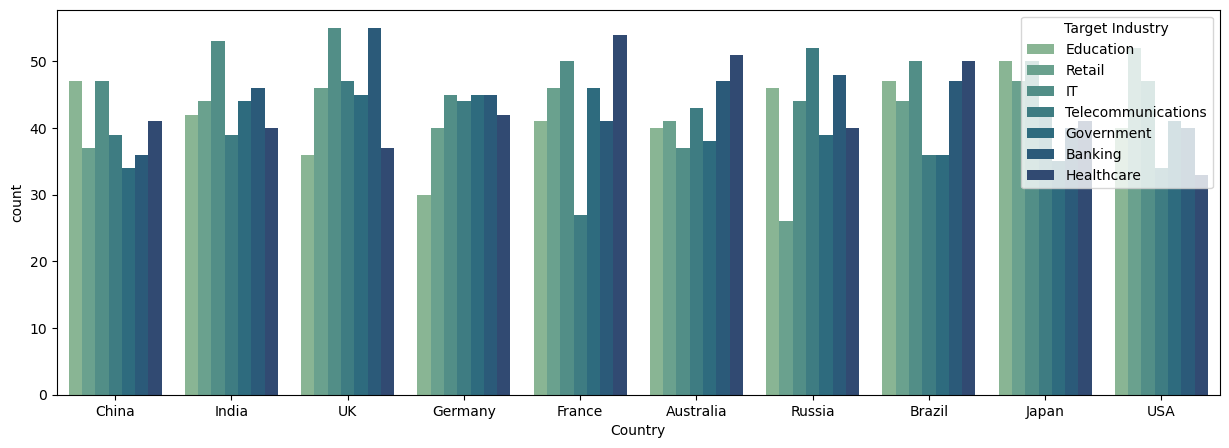

In [423]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Country"],hue =cyber["Target Industry"],palette="crest")

In [305]:
chi_square("Country","Attack Source")

Actual values:

Attack Source  Hacker Group  Insider  Nation-state  Unknown
Country                                                    
Australia                62       81            80       74
Brazil                   77       70            77       86
China                    60       73            76       72
France                   70       72            80       83
Germany                  72       71            77       71
India                    67       88            72       81
Japan                    63       74            96       72
Russia                   61       80            80       74
UK                       89       68            84       80
USA                      65       75            72       75
Expected values: 

[[67.914      74.448      78.606      76.032     ]
 [70.88666667 77.70666667 82.04666667 79.36      ]
 [64.25533333 70.43733333 74.37133333 71.936     ]
 [69.74333333 76.45333333 80.72333333 78.08      ]
 [66.542      72.944      77.018      74.

<Axes: xlabel='Country', ylabel='count'>

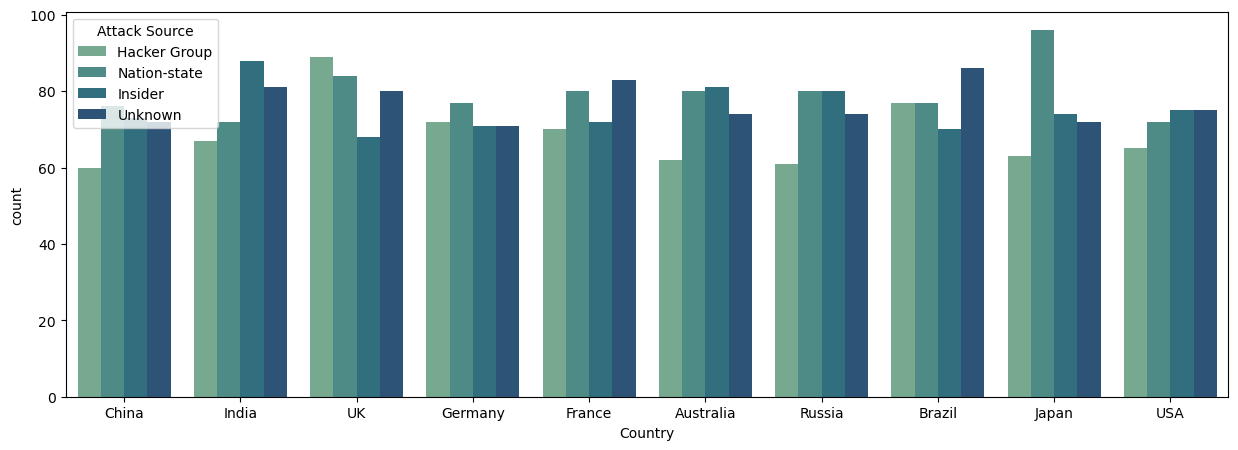

In [419]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Country"],hue =cyber["Attack Source"],palette="crest")

In [307]:
chi_square("Country","Security Vulnerability Type")

Actual values:

Security Vulnerability Type  Social Engineering  Unpatched Software  \
Country                                                               
Australia                                    70                  74   
Brazil                                       81                  62   
China                                        78                  60   
France                                       77                  77   
Germany                                      65                  82   
India                                        65                  94   
Japan                                        74                  66   
Russia                                       74                  76   
UK                                           88                  82   
USA                                          75                  65   

Security Vulnerability Type  Weak Passwords  Zero-day  
Country                                                
Australia          

<Axes: xlabel='Country', ylabel='count'>

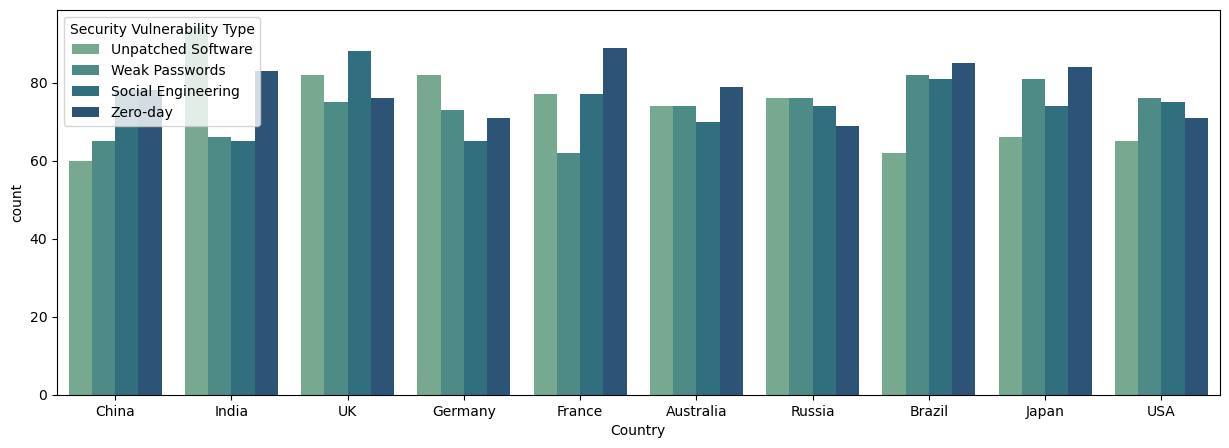

In [421]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Country"],hue =cyber["Security Vulnerability Type"],palette="crest")

In [309]:
chi_square("Country","Defense Mechanism Used")

Actual values:

Defense Mechanism Used  AI-based Detection  Antivirus  Encryption  Firewall  \
Country                                                                       
Australia                               50         79          50        61   
Brazil                                  64         55          82        61   
China                                   49         64          48        63   
France                                  59         65          61        57   
Germany                                 67         63          63        40   
India                                   63         64          51        59   
Japan                                   63         56          58        60   
Russia                                  58         55          60        59   
UK                                      55         68          62        70   
USA                                     55         59          57        55   

Defense Mechanism Used  VPN  
Count

<Axes: xlabel='Country', ylabel='count'>

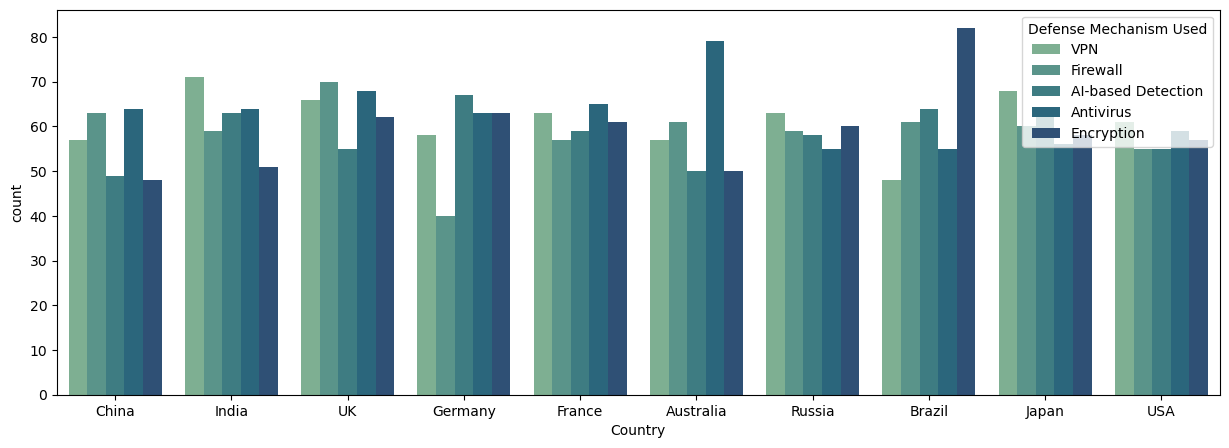

In [415]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Country"],hue =cyber["Defense Mechanism Used"],palette="crest")

In [311]:
chi_square("Attack Type","Target Industry")

Actual values:

Target Industry    Banking  Education  Government  Healthcare  IT  Retail  \
Attack Type                                                                 
DDoS                    71         73          71          78  91      62   
Malware                 61         70          64          81  67      68   
Man-in-the-Middle       77         65          53          58  80      70   
Phishing                96         73          68          63  89      89   
Ransomware              69         71          72          77  74      71   
SQL Injection           71         67          75          72  77      63   

Target Industry    Telecommunications  
Attack Type                            
DDoS                               85  
Malware                            74  
Man-in-the-Middle                  56  
Phishing                           51  
Ransomware                         59  
SQL Injection                      78  
Expected values: 

[[78.765      74.163      71

<Axes: xlabel='Attack Type', ylabel='count'>

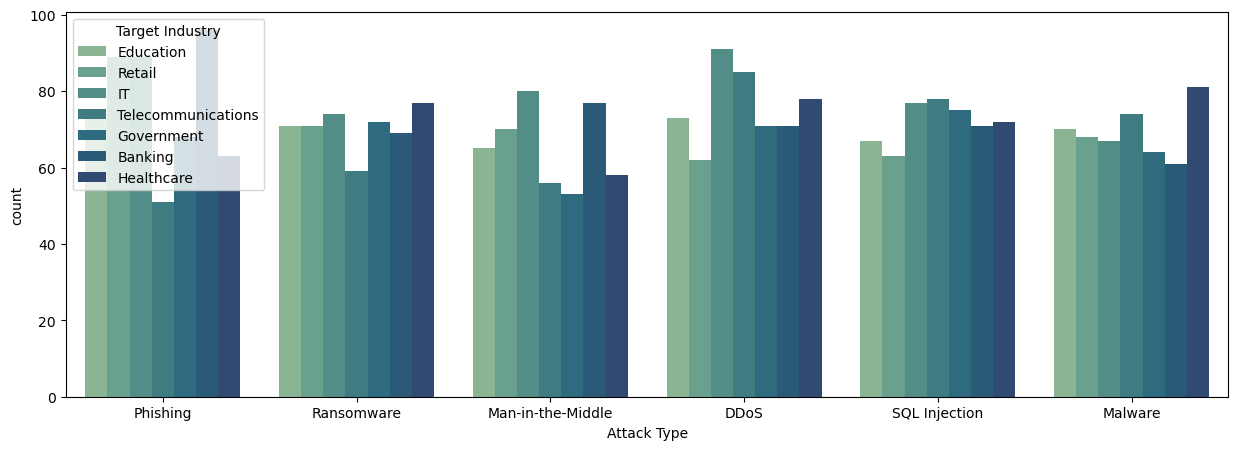

In [413]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Type"],hue =cyber["Target Industry"],palette="crest")

In [313]:
chi_square("Attack Type","Attack Source")

Actual values:

Attack Source      Hacker Group  Insider  Nation-state  Unknown
Attack Type                                                    
DDoS                        122      147           137      125
Malware                     117      121           124      123
Man-in-the-Middle           107      107           131      114
Phishing                    125      129           141      134
Ransomware                  118      121           123      131
SQL Injection                97      127           138      141
Expected values: 

[[121.422      133.104      140.538      135.936     ]
 [110.90333333 121.57333333 128.36333333 124.16      ]
 [104.958      115.056      121.482      117.504     ]
 [120.96466667 132.60266667 140.00866667 135.424     ]
 [112.73266667 123.57866667 130.48066667 126.208     ]
 [115.01933333 126.08533333 133.12733333 128.768     ]]

Chi-square is : 9.708513485314697 

p_value is : 0.8376636111561695 

degree of freedom is :15

There is no correlation b

<Axes: xlabel='Attack Type', ylabel='count'>

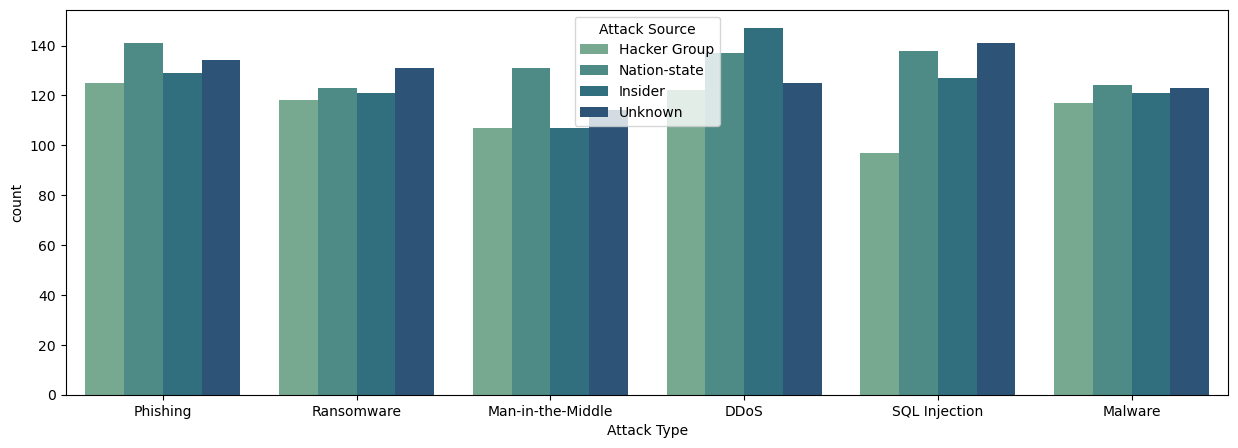

In [411]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Type"],hue =cyber["Attack Source"],palette="crest")

In [315]:
chi_square("Attack Type","Security Vulnerability Type")

Actual values:

Security Vulnerability Type  Social Engineering  Unpatched Software  \
Attack Type                                                           
DDoS                                        132                 127   
Malware                                     130                 107   
Man-in-the-Middle                           104                 135   
Phishing                                    124                 121   
Ransomware                                  141                 124   
SQL Injection                               116                 124   

Security Vulnerability Type  Weak Passwords  Zero-day  
Attack Type                                            
DDoS                                    146       126  
Malware                                 113       135  
Man-in-the-Middle                       102       118  
Phishing                                124       160  
Ransomware                              116       112  
SQL Injection          

<Axes: xlabel='Attack Type', ylabel='count'>

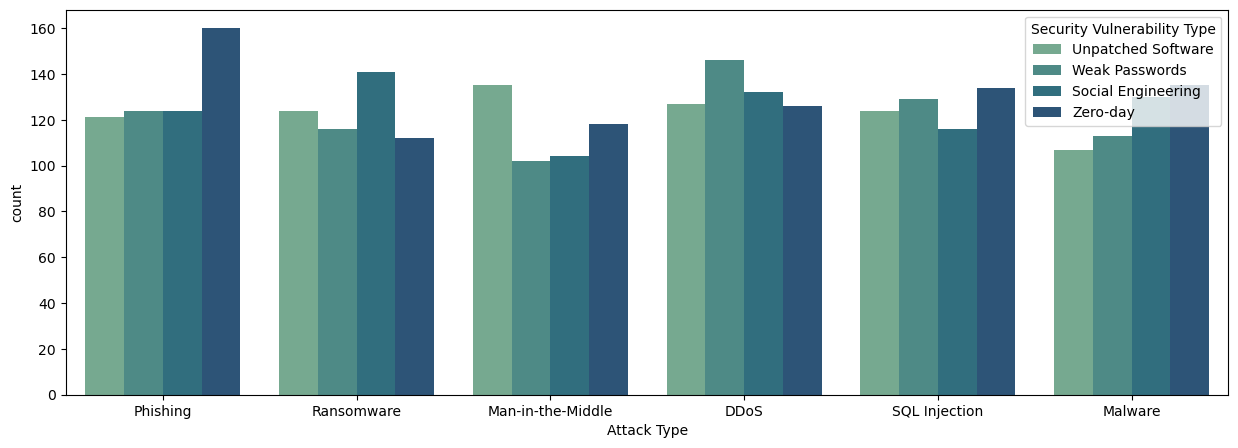

In [409]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Type"],hue =cyber["Security Vulnerability Type"],palette="crest")

In [317]:
chi_square("Attack Type","Defense Mechanism Used")

Actual values:

Defense Mechanism Used  AI-based Detection  Antivirus  Encryption  Firewall  \
Attack Type                                                                   
DDoS                                   113        103          92       103   
Malware                                102        111          86        99   
Man-in-the-Middle                       85         87          95       106   
Phishing                                92        111         121        93   
Ransomware                              97        103          91        98   
SQL Injection                           94        113         107        86   

Defense Mechanism Used  VPN  
Attack Type                  
DDoS                    120  
Malware                  87  
Man-in-the-Middle        86  
Phishing                112  
Ransomware              104  
SQL Injection           103  
Expected values: 

[[103.191      111.156      104.784      103.545      108.324     ]
 [ 94.25166667 101.52666

<Axes: xlabel='Attack Type', ylabel='count'>

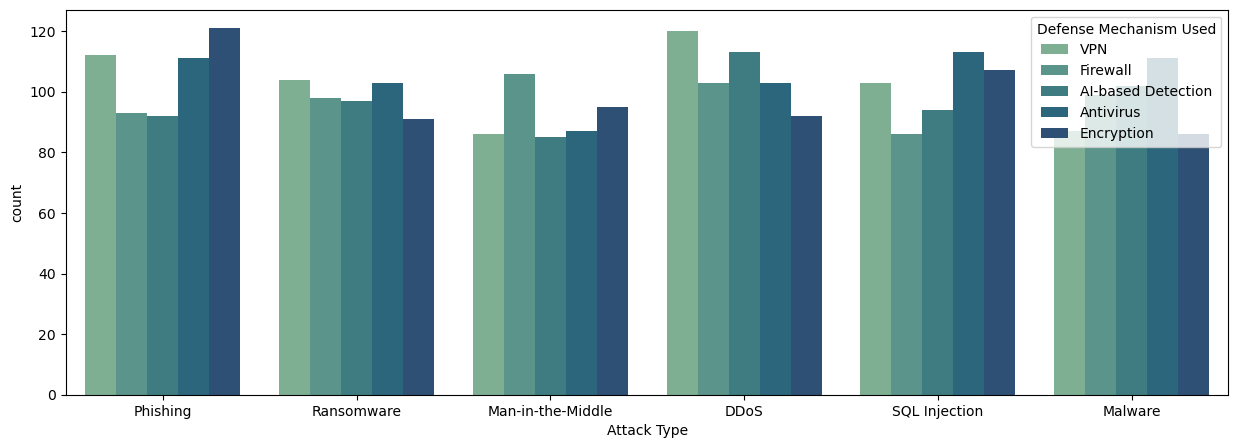

In [407]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Type"],hue =cyber["Defense Mechanism Used"],palette="crest")

In [319]:
chi_square("Target Industry","Attack Source")

Actual values:

Attack Source       Hacker Group  Insider  Nation-state  Unknown
Target Industry                                                 
Banking                       94      126           122      103
Education                     80      126           125       88
Government                   101       95           101      106
Healthcare                   104      103           101      121
IT                           111      108           110      149
Retail                        99       91           125      108
Telecommunications            97      103           110       93
Expected values: 

[[101.75666667 111.54666667 117.77666667 113.92      ]
 [ 95.81133333 105.02933333 110.89533333 107.264     ]
 [ 92.15266667 101.01866667 106.66066667 103.168     ]
 [ 98.098      107.536      113.542      109.824     ]
 [109.30266667 119.81866667 126.51066667 122.368     ]
 [ 96.726      106.032      111.954      108.288     ]
 [ 92.15266667 101.01866667 106.66066667 103.168  

<Axes: xlabel='Target Industry', ylabel='count'>

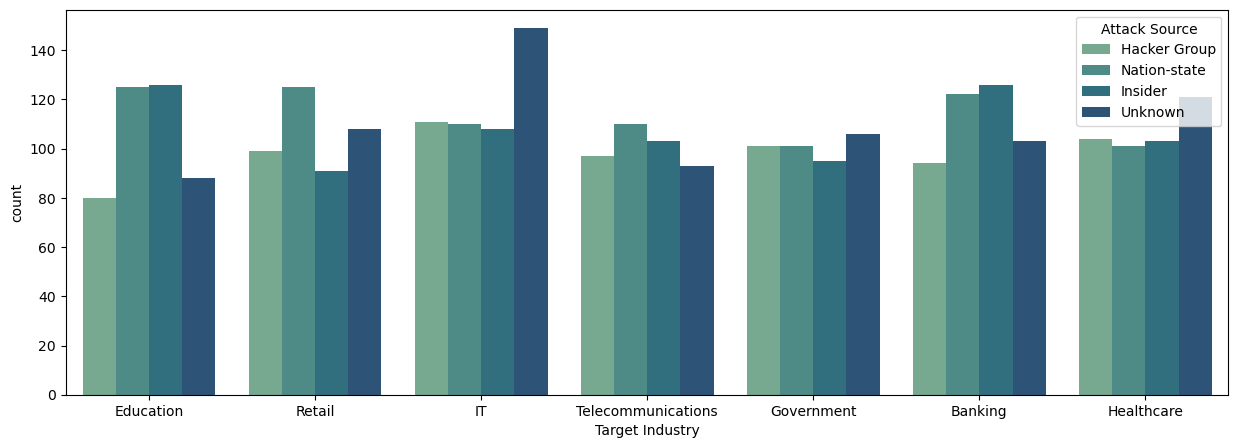

In [358]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Target Industry"],hue =cyber["Attack Source"],palette="crest")

In [ ]:
#There is significance in this area.

In [321]:
chi_square("Target Industry","Security Vulnerability Type")

Actual values:

Security Vulnerability Type  Social Engineering  Unpatched Software  \
Target Industry                                                       
Banking                                     117                 107   
Education                                   115                 101   
Government                                   96                  97   
Healthcare                                  112                 105   
IT                                          107                 112   
Retail                                       97                 109   
Telecommunications                          103                 107   

Security Vulnerability Type  Weak Passwords  Zero-day  
Target Industry                                        
Banking                                 111       110  
Education                                94       109  
Government                               98       112  
Healthcare                              115        97  
IT      

<Axes: xlabel='Target Industry', ylabel='count'>

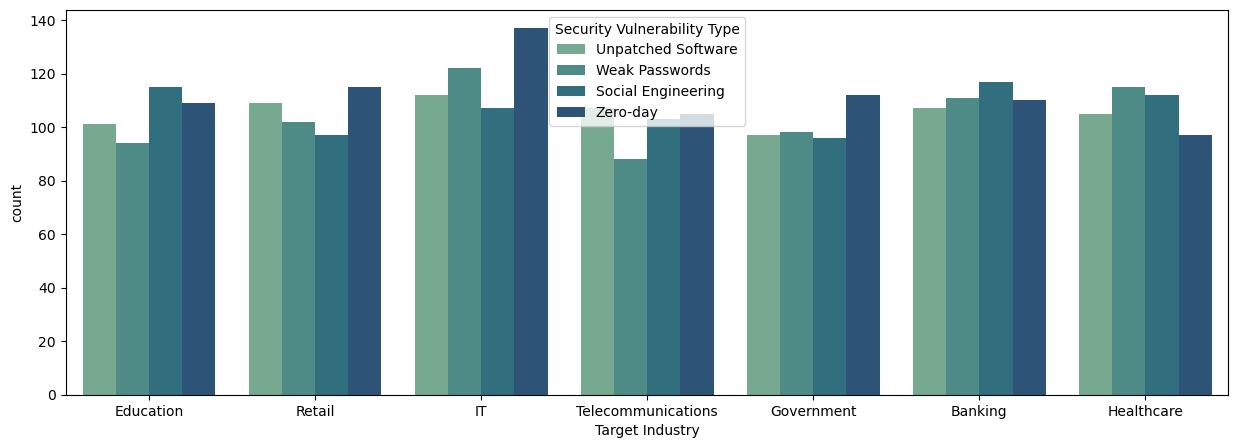

In [405]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Target Industry"],hue =cyber["Security Vulnerability Type"],palette="crest")

In [323]:
chi_square("Target Industry","Defense Mechanism Used")

Actual values:

Defense Mechanism Used  AI-based Detection  Antivirus  Encryption  Firewall  \
Target Industry                                                               
Banking                                 87         89          86        83   
Education                               88         86          83        83   
Government                              65         87          80        89   
Healthcare                              76         96          88        89   
IT                                     101         90         117        81   
Retail                                  82         97          65        90   
Telecommunications                      84         83          73        70   

Defense Mechanism Used  VPN  
Target Industry              
Banking                 100  
Education                79  
Government               82  
Healthcare               80  
IT                       89  
Retail                   89  
Telecommunications       93  
Ex

<Axes: xlabel='Target Industry', ylabel='count'>

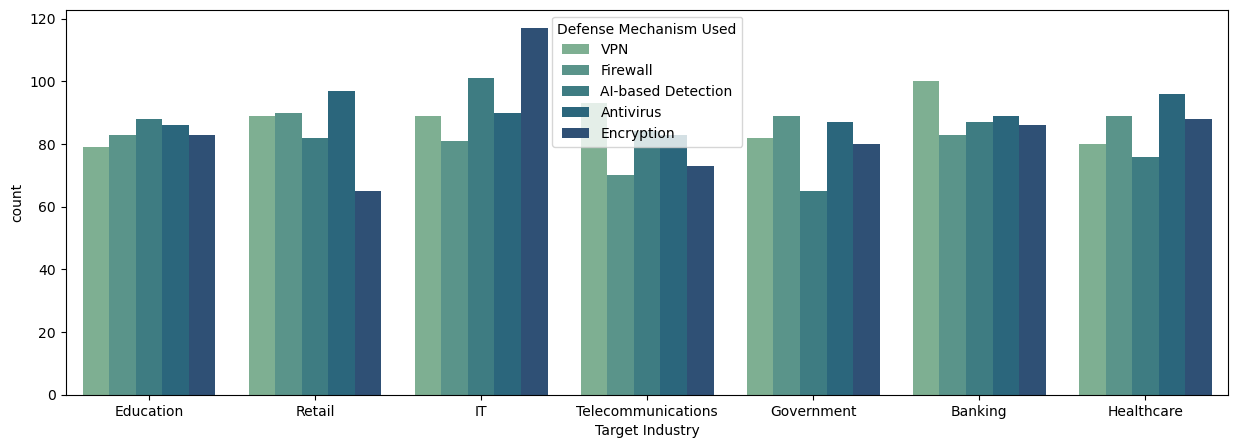

In [403]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Target Industry"],hue =cyber["Defense Mechanism Used"],palette="crest")

In [325]:
chi_square("Attack Source","Security Vulnerability Type")

Actual values:

Security Vulnerability Type  Social Engineering  Unpatched Software  \
Attack Source                                                         
Hacker Group                                190                 159   
Insider                                     186                 202   
Nation-state                                190                 194   
Unknown                                     181                 183   

Security Vulnerability Type  Weak Passwords  Zero-day  
Attack Source                                          
Hacker Group                            164       173  
Insider                                 183       181  
Nation-state                            194       216  
Unknown                                 189       215  
Expected values: 

[[170.814      168.756      166.92666667 179.50333333]
 [187.248      184.992      182.98666667 196.77333333]
 [197.706      195.324      193.20666667 207.76333333]
 [191.232      188.928      186.88   

<Axes: xlabel='Attack Source', ylabel='count'>

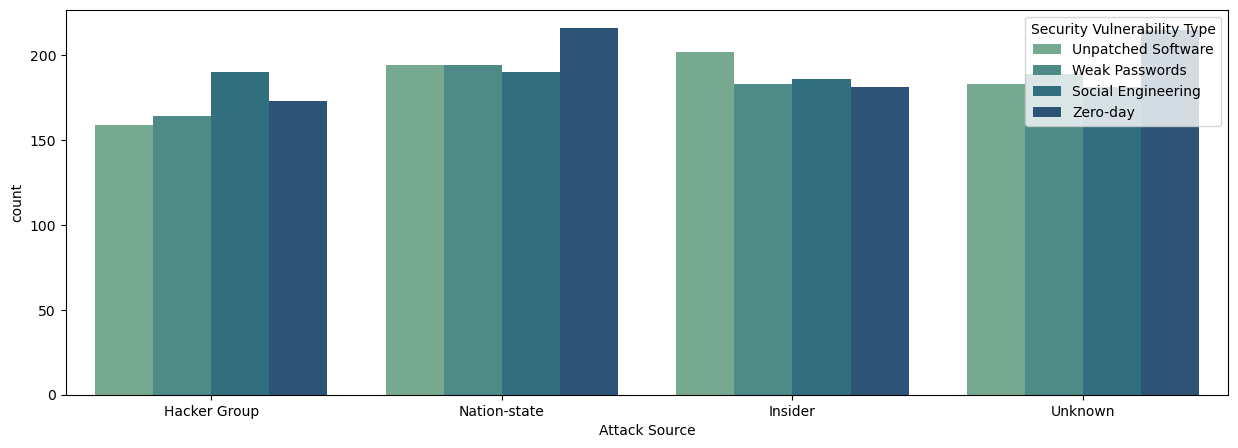

In [401]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Source"],hue =cyber["Security Vulnerability Type"],palette="crest")

In [327]:
chi_square("Attack Source","Defense Mechanism Used")

Actual values:

Defense Mechanism Used  AI-based Detection  Antivirus  Encryption  Firewall  \
Attack Source                                                                 
Hacker Group                           136        138         141       127   
Insider                                161        136         134       153   
Nation-state                           148        188         157       148   
Unknown                                138        166         160       157   

Defense Mechanism Used  VPN  
Attack Source                
Hacker Group            144  
Insider                 168  
Nation-state            153  
Unknown                 147  
Expected values: 

[[133.31266667 143.60266667 135.37066667 133.77       139.944     ]
 [146.13866667 157.41866667 148.39466667 146.64       153.408     ]
 [154.30066667 166.21066667 156.68266667 154.83       161.976     ]
 [149.248      160.768      151.552      149.76       156.672     ]]

Chi-square is : 14.801812277827132 


<Axes: xlabel='Attack Source', ylabel='count'>

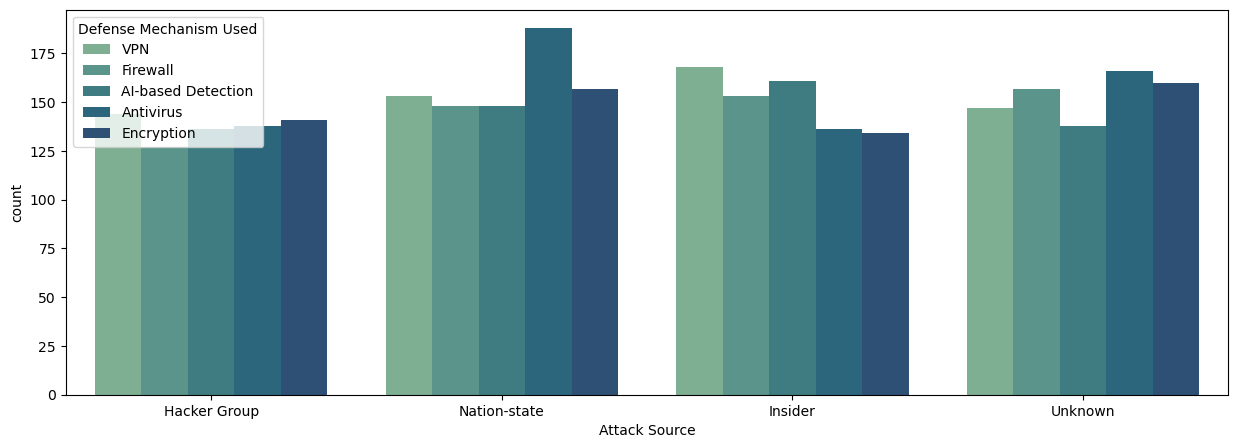

In [399]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Source"],hue =cyber["Defense Mechanism Used"],palette="crest")

In [329]:
chi_square("Security Vulnerability Type","Defense Mechanism Used")

Actual values:

Defense Mechanism Used       AI-based Detection  Antivirus  Encryption  \
Security Vulnerability Type                                              
Social Engineering                          144        156         143   
Unpatched Software                          135        152         151   
Weak Passwords                              139        163         150   
Zero-day                                    165        157         148   

Defense Mechanism Used       Firewall  VPN  
Security Vulnerability Type                 
Social Engineering                152  152  
Unpatched Software                150  150  
Weak Passwords                    134  144  
Zero-day                          149  166  
Expected values: 

[[145.167      156.372      147.408      145.665      152.388     ]
 [143.418      154.488      145.632      143.91       150.552     ]
 [141.86333333 152.81333333 144.05333333 142.35       148.92      ]
 [152.55166667 164.32666667 154.90666667 153.0

<Axes: xlabel='Security Vulnerability Type', ylabel='count'>

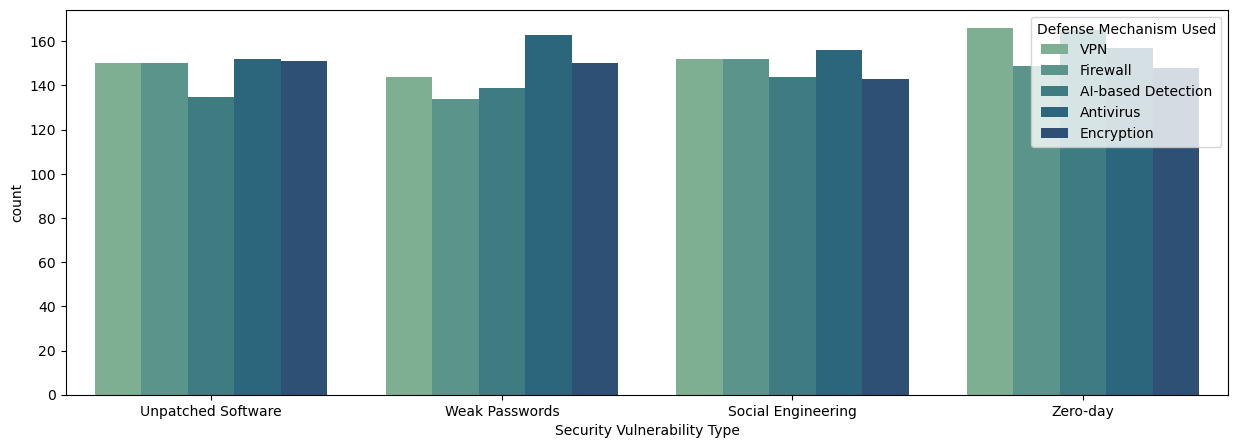

In [397]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Security Vulnerability Type"],hue =cyber["Defense Mechanism Used"],palette="crest")

In [366]:
chi_square("Year","Country")

Actual values:

Country  Australia  Brazil  China  France  Germany  India  Japan  Russia  UK  \
Year                                                                           
2015            22      26     24      30       21     32     29      31  34   
2016            34      29     29      28       34     22     16      23  36   
2017            28      37     23      40       34     28     41      28  27   
2018            32      33     22      28       32     41     29      33  29   
2019            27      27     25      29       20     29     22      28  32   
2020            23      30     28      38       27     35     38      30  33   
2021            27      34     31      32       28     24     31      29  35   
2022            39      25     31      26       33     29     39      35  36   
2023            31      34     31      28       33     38     35      24  32   
2024            34      35     37      26       29     30     25      34  27   

Country  USA  
Year    

<Axes: xlabel='Year', ylabel='count'>

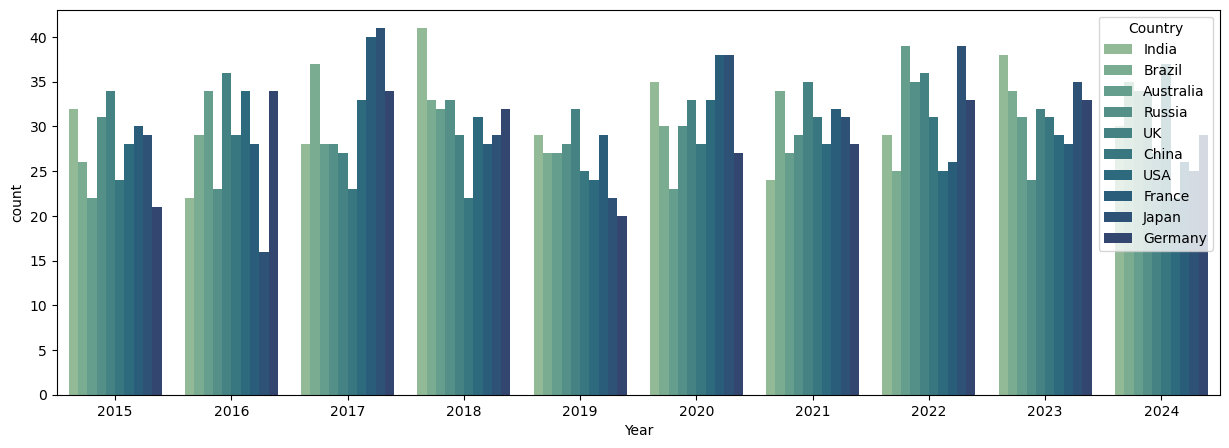

In [395]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Year"],hue =cyber["Country"],palette="crest")

In [368]:
chi_square("Year","Attack Type")

Actual values:

Attack Type  DDoS  Malware  Man-in-the-Middle  Phishing  Ransomware  \
Year                                                                  
2015           50       51                 41        46          47   
2016           53       41                 47        55          42   
2017           58       46                 58        64          44   
2018           60       56                 36        52          49   
2019           48       43                 44        45          38   
2020           56       37                 47        61          59   
2021           47       49                 48        41          55   
2022           54       64                 41        57          56   
2023           51       55                 50        46          50   
2024           54       43                 47        62          53   

Attack Type  SQL Injection  
Year                        
2015                    42  
2016                    47  
2017           

<Axes: xlabel='Year', ylabel='count'>

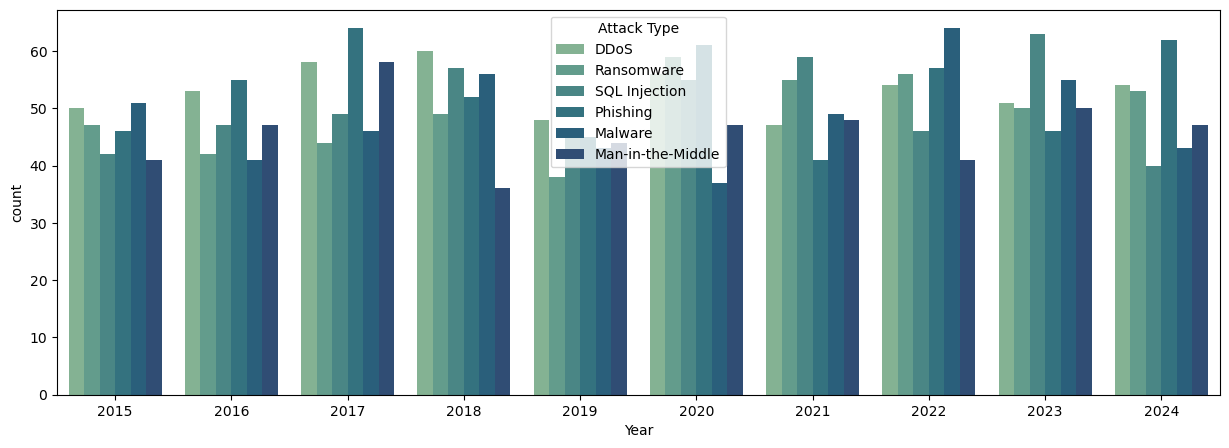

In [393]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Year"],hue =cyber["Attack Type"],palette="crest")

In [370]:
chi_square("Year","Target Industry")

Actual values:

Target Industry  Banking  Education  Government  Healthcare  IT  Retail  \
Year                                                                      
2015                  43         30          37          36  53      42   
2016                  36         42          41          42  46      40   
2017                  45         43          46          56  56      40   
2018                  50         59          40          46  40      41   
2019                  44         35          39          32  40      31   
2020                  52         43          38          50  48      44   
2021                  51         38          39          42  38      42   
2022                  42         49          35          40  57      49   
2023                  49         42          39          43  52      47   
2024                  33         38          49          42  48      47   

Target Industry  Telecommunications  
Year                                 
2015   

<Axes: xlabel='Year', ylabel='count'>

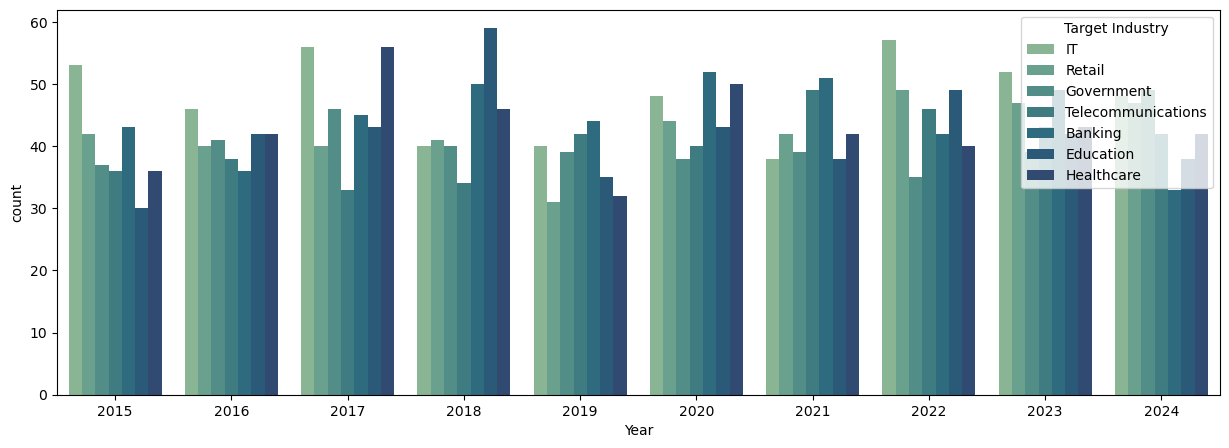

In [391]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Year"],hue =cyber["Target Industry"],palette="crest")

In [372]:
chi_square("Year","Attack Source")

Actual values:

Attack Source  Hacker Group  Insider  Nation-state  Unknown
Year                                                       
2015                     56       68            78       75
2016                     67       59            78       81
2017                     89       73            81       76
2018                     75       86            74       75
2019                     48       73            79       63
2020                     68       87            80       80
2021                     73       74            85       67
2022                     61       90            82       85
2023                     77       69            84       85
2024                     72       73            73       81
Expected values: 

[[63.34066667 69.43466667 73.31266667 70.912     ]
 [65.17       71.44       75.43       72.96      ]
 [72.94466667 79.96266667 84.42866667 81.664     ]
 [70.88666667 77.70666667 82.04666667 79.36      ]
 [60.13933333 65.92533333 69.60733333 67.

<Axes: xlabel='Year', ylabel='count'>

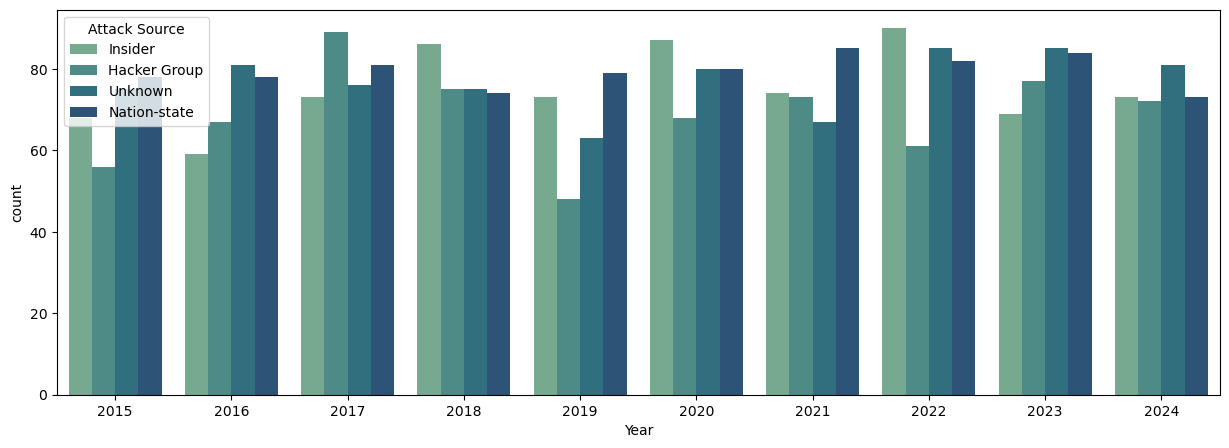

In [389]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Year"],hue =cyber["Attack Source"],palette="crest")

In [374]:
chi_square("Year","Security Vulnerability Type")

Actual values:

Security Vulnerability Type  Social Engineering  Unpatched Software  \
Year                                                                  
2015                                         68                  71   
2016                                         79                  72   
2017                                         74                  75   
2018                                         78                  73   
2019                                         67                  59   
2020                                         71                  87   
2021                                         78                  70   
2022                                         78                  80   
2023                                         75                  83   
2024                                         79                  68   

Security Vulnerability Type  Weak Passwords  Zero-day  
Year                                                   
2015               

<Axes: xlabel='Year', ylabel='count'>

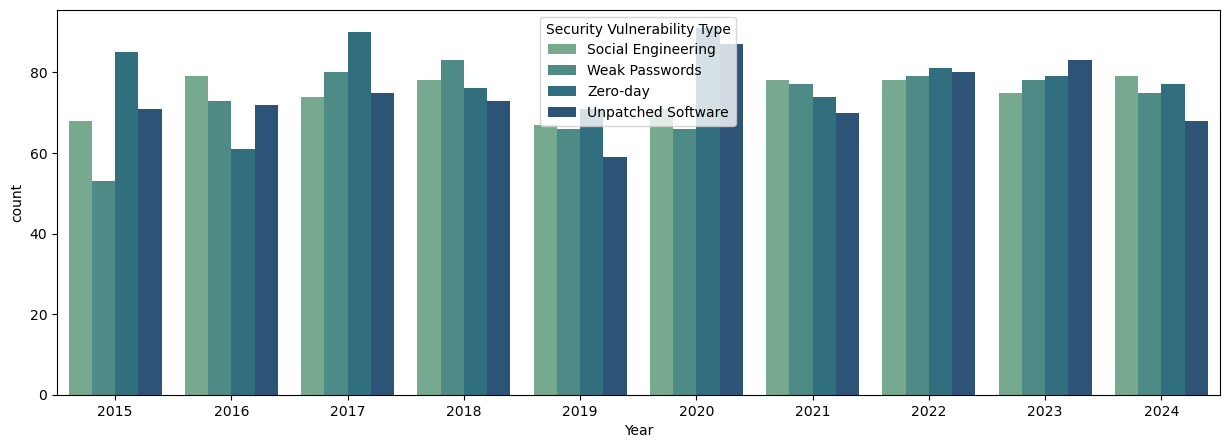

In [387]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Year"],hue =cyber["Security Vulnerability Type"],palette="crest")

In [362]:
chi_square("Year","Defense Mechanism Used")

Actual values:

Defense Mechanism Used  AI-based Detection  Antivirus  Encryption  Firewall  \
Year                                                                          
2015                                    58         52          54        52   
2016                                    54         63          56        52   
2017                                    80         59          67        62   
2018                                    50         73          59        61   
2019                                    43         57          50        57   
2020                                    54         63          67        67   
2021                                    60         76          55        54   
2022                                    72         59          66        55   
2023                                    66         62          62        63   
2024                                    46         64          56        62   

Defense Mechanism Used  VPN  
Year 

<Axes: xlabel='Year', ylabel='count'>

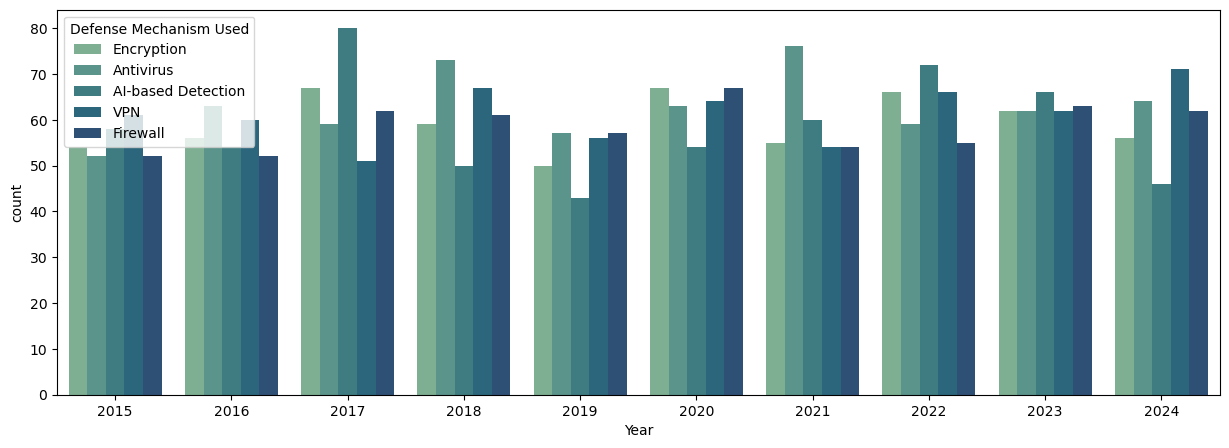

In [385]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Year"],hue =cyber["Defense Mechanism Used"],palette="crest")

In [263]:
corr=cyber.corr(numeric_only=True)

In [265]:
corr

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
Year,1.000000,0.010581,0.002317,-0.004982
Financial Loss (in Million $),0.010581,1.000000,0.001787,-0.012671
Number of Affected Users,0.002317,0.001787,1.000000,0.005893
Incident Resolution Time (in Hours),-0.004982,-0.012671,0.005893,1.000000


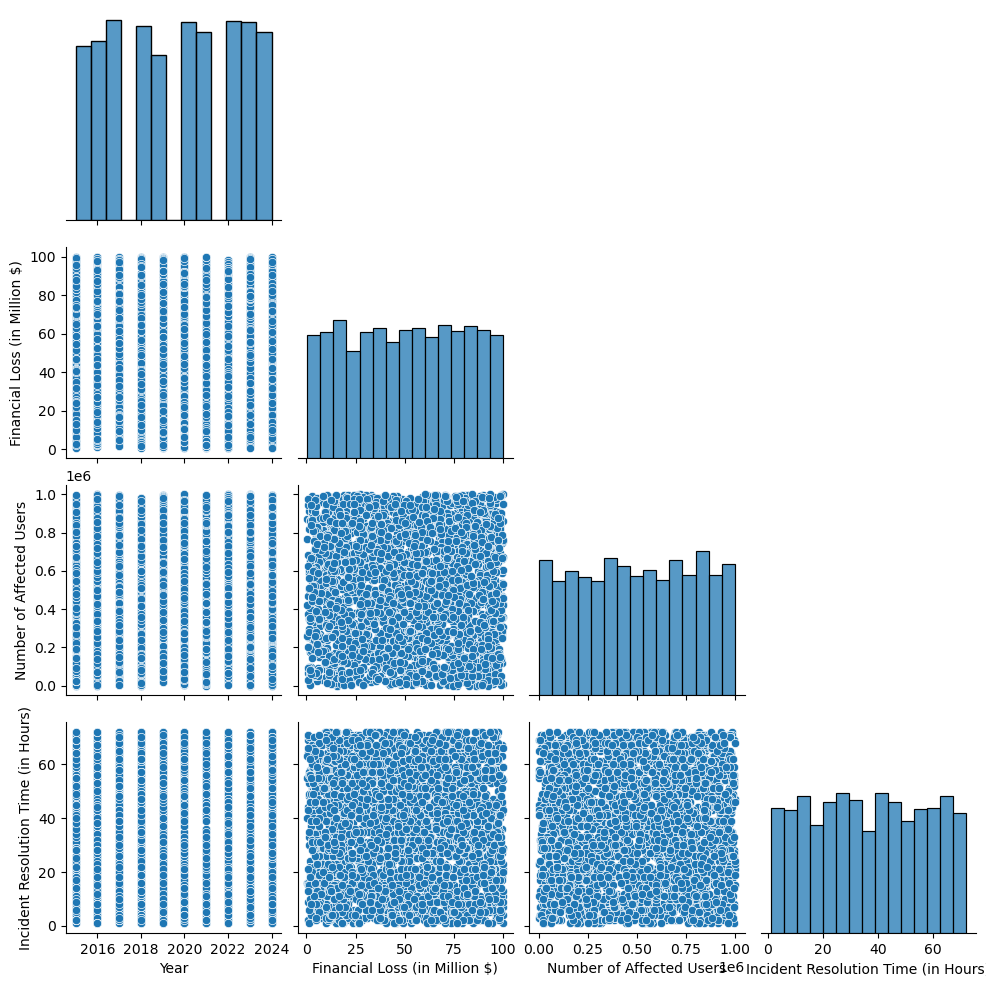

In [462]:
plt.rcParams["figure.figsize"] = (5,5)
sns.pairplot(cyber, corner=True,)

<Axes: >

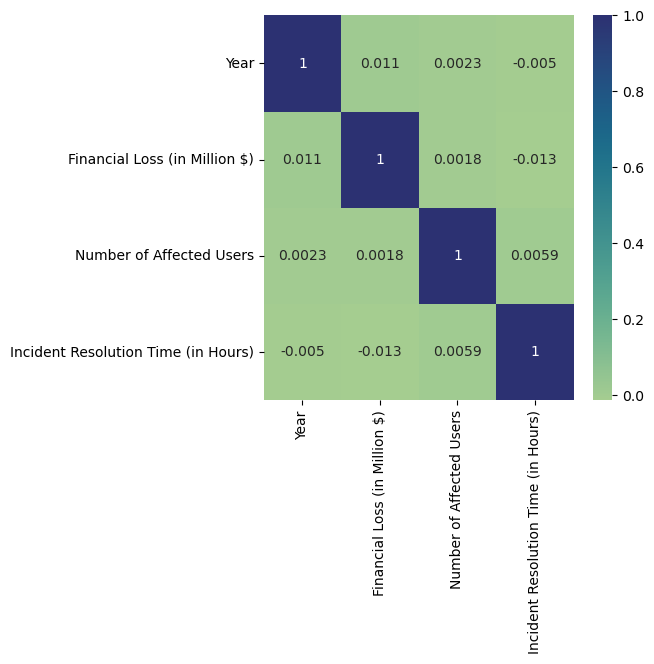

In [464]:
sns.heatmap(corr, annot=True, cmap='crest')

In [ ]:
#No Correlations Here to remove.

In [291]:
df1=cyber.astype({'Year':'object'})

In [300]:
df1.dtypes

Country                                 object
Year                                    object
Attack Type                             object
Target Industry                         object
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                           object
Security Vulnerability Type             object
Defense Mechanism Used                  object
Incident Resolution Time (in Hours)      int64
dtype: object

In [ ]:
#now doing year as object in chisquare

<Axes: xlabel='Country', ylabel='count'>

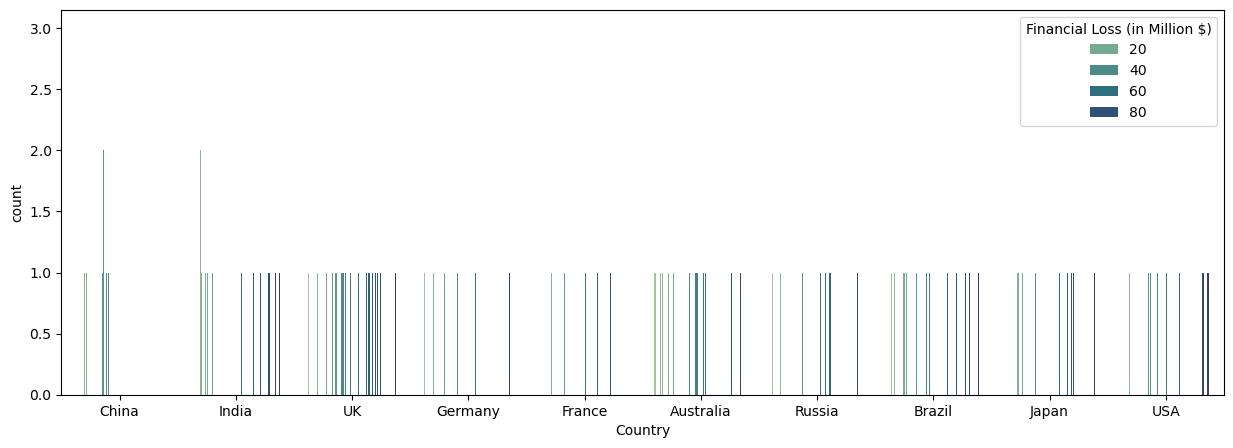

In [908]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Country"],hue =cyber["Financial Loss (in Million $)"],palette="crest")

<Axes: xlabel='Attack Type', ylabel='count'>

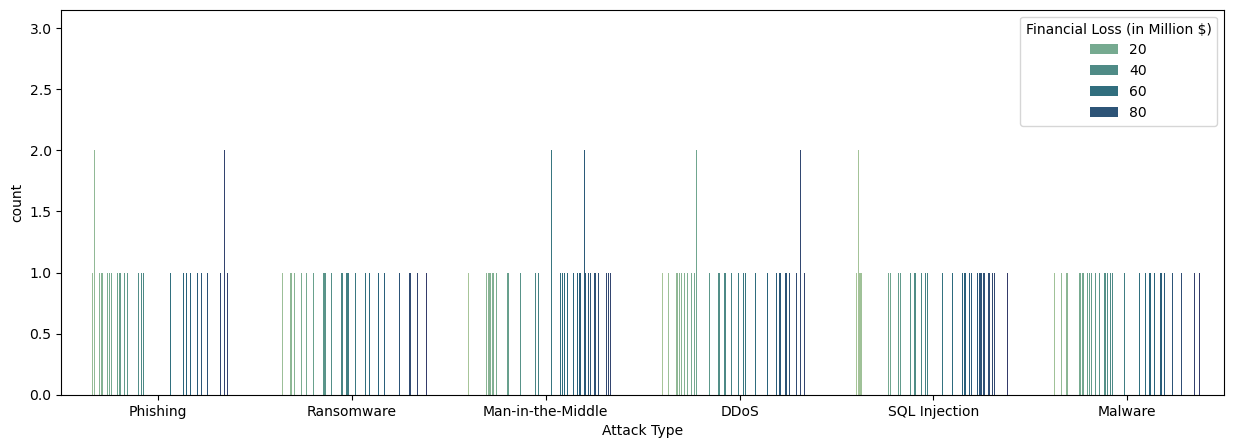

In [927]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Type"],hue =cyber["Financial Loss (in Million $)"],palette="crest")

<Axes: xlabel='Target Industry', ylabel='count'>

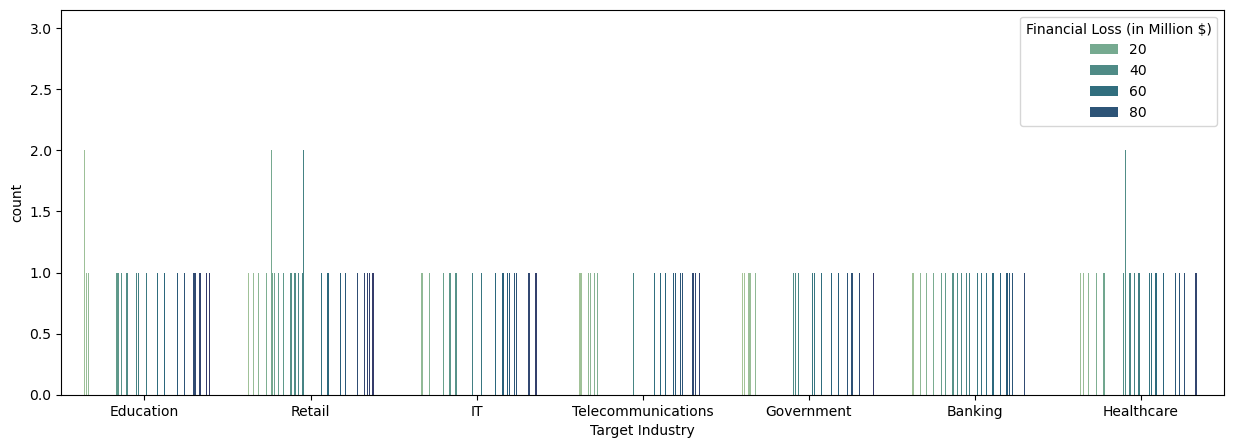

In [929]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Target Industry"],hue =cyber["Financial Loss (in Million $)"],palette="crest")

<Axes: xlabel='Attack Source', ylabel='count'>

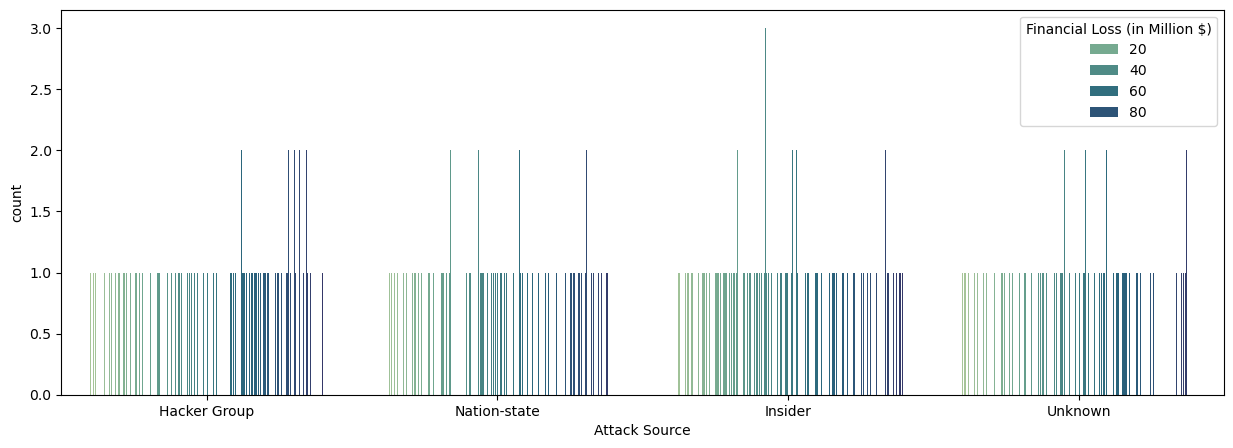

In [930]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Source"],hue =cyber["Financial Loss (in Million $)"],palette="crest")

<Axes: xlabel='Security Vulnerability Type', ylabel='count'>

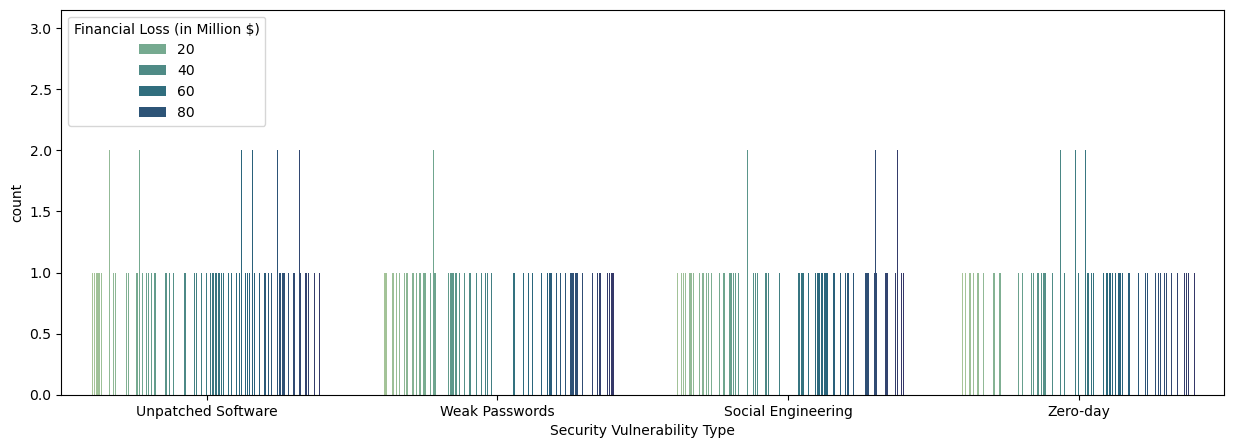

In [931]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Security Vulnerability Type"],hue =cyber["Financial Loss (in Million $)"],palette="crest")

<Axes: xlabel='Defense Mechanism Used', ylabel='count'>

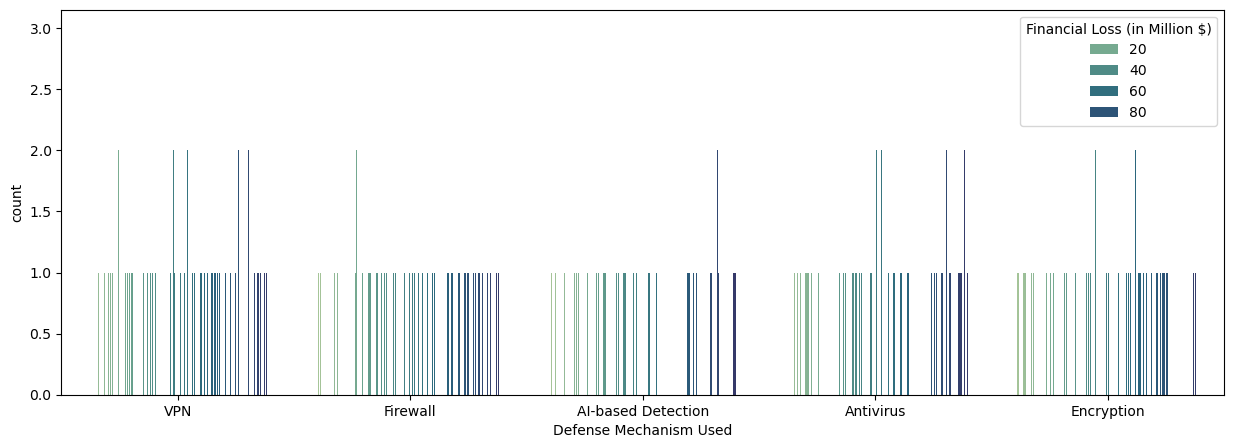

In [967]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Defense Mechanism Used"],hue =cyber["Financial Loss (in Million $)"],palette="crest")

<Axes: xlabel='Country', ylabel='count'>

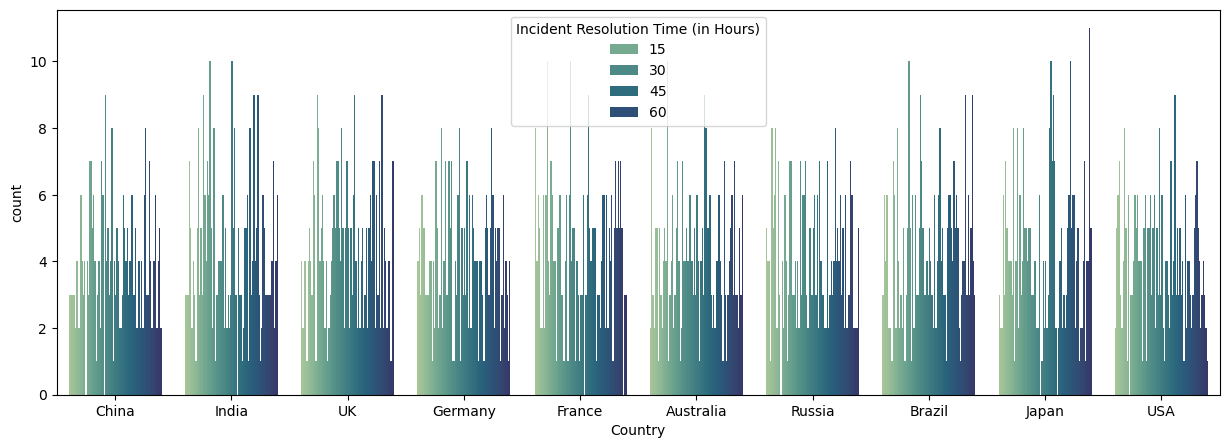

In [947]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Country"],hue =cyber["Incident Resolution Time (in Hours)"],palette="crest")

<Axes: xlabel='Attack Type', ylabel='count'>

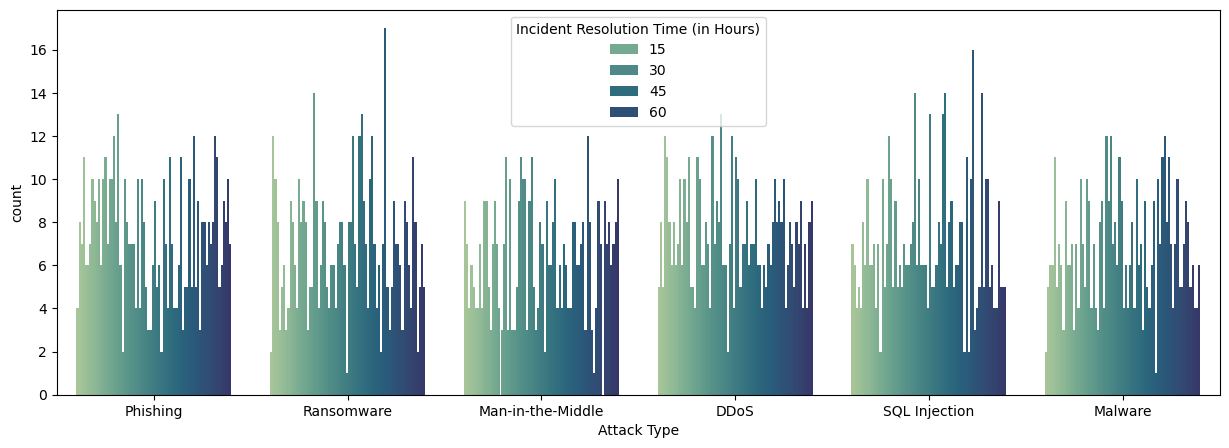

In [949]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Type"],hue =cyber["Incident Resolution Time (in Hours)"],palette="crest")

<Axes: xlabel='Target Industry', ylabel='count'>

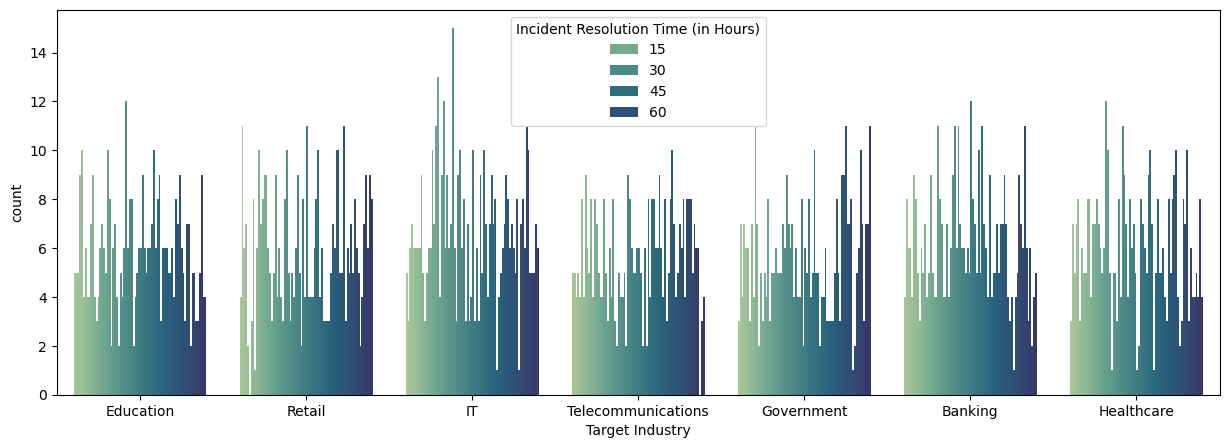

In [951]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Target Industry"],hue =cyber["Incident Resolution Time (in Hours)"],palette="crest")

<Axes: xlabel='Attack Source', ylabel='count'>

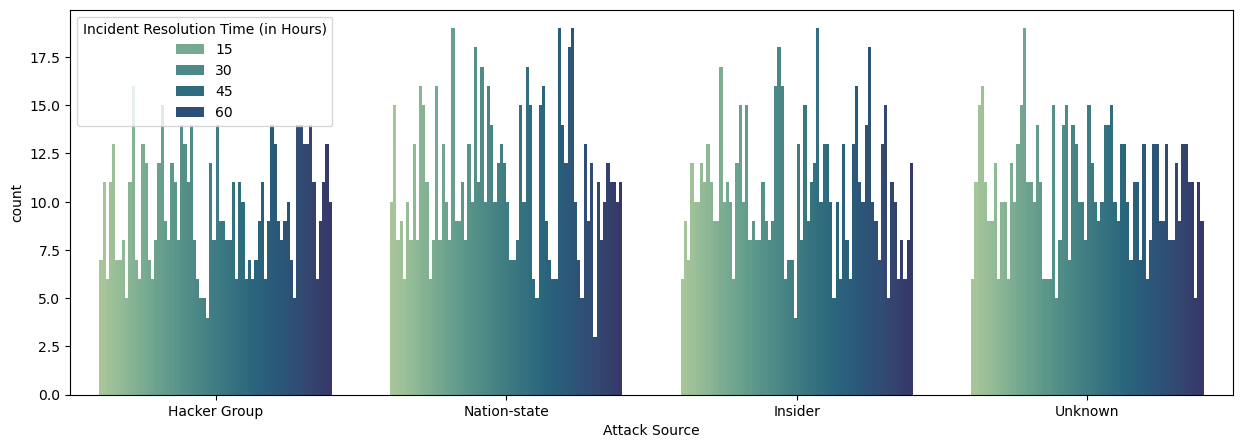

In [952]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Source"],hue =cyber["Incident Resolution Time (in Hours)"],palette="crest")

<Axes: xlabel='Security Vulnerability Type', ylabel='count'>

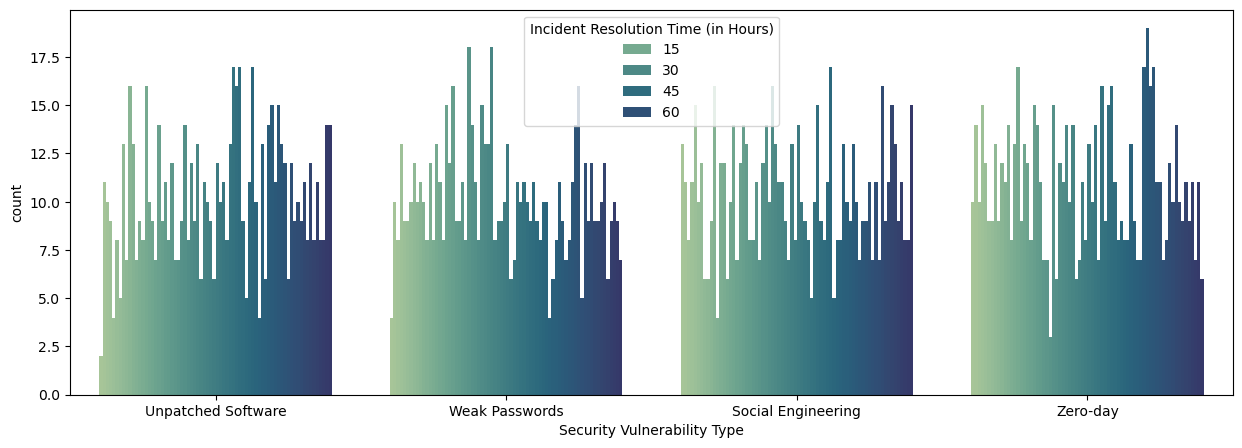

In [953]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Security Vulnerability Type"],hue =cyber["Incident Resolution Time (in Hours)"],palette="crest")

<Axes: xlabel='Defense Mechanism Used', ylabel='count'>

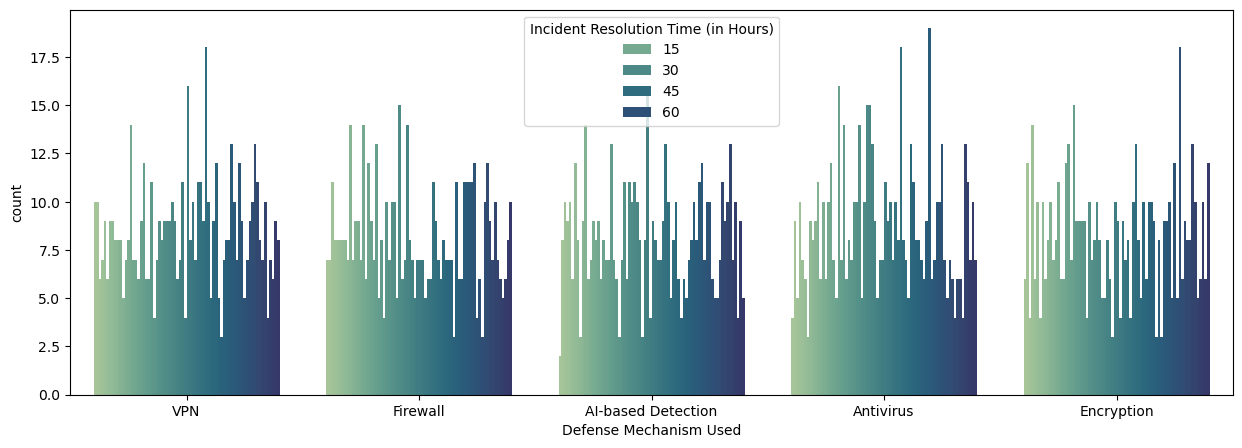

In [954]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Defense Mechanism Used"],hue =cyber["Incident Resolution Time (in Hours)"],palette="crest")

<Axes: xlabel='Country', ylabel='count'>

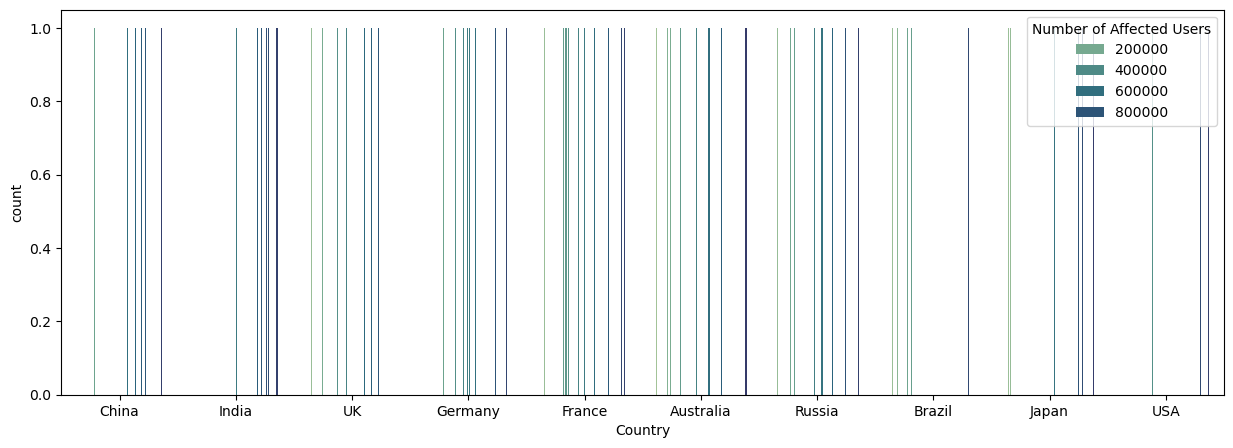

In [956]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Country"],hue =cyber["Number of Affected Users"],palette="crest")

<Axes: xlabel='Attack Type', ylabel='count'>

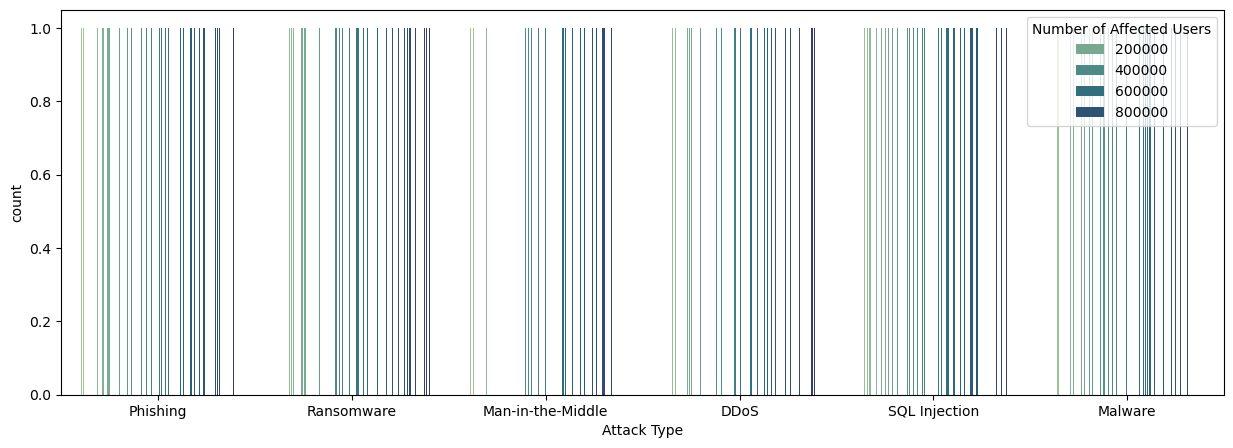

In [960]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Type"],hue =cyber["Number of Affected Users"],palette="crest")

<Axes: xlabel='Target Industry', ylabel='count'>

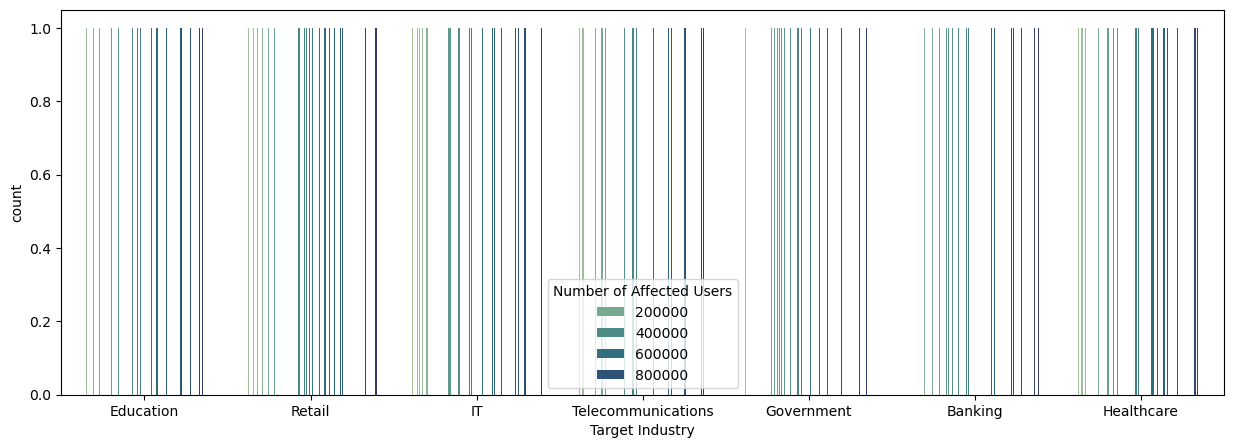

In [961]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Target Industry"],hue =cyber["Number of Affected Users"],palette="crest")

<Axes: xlabel='Attack Source', ylabel='count'>

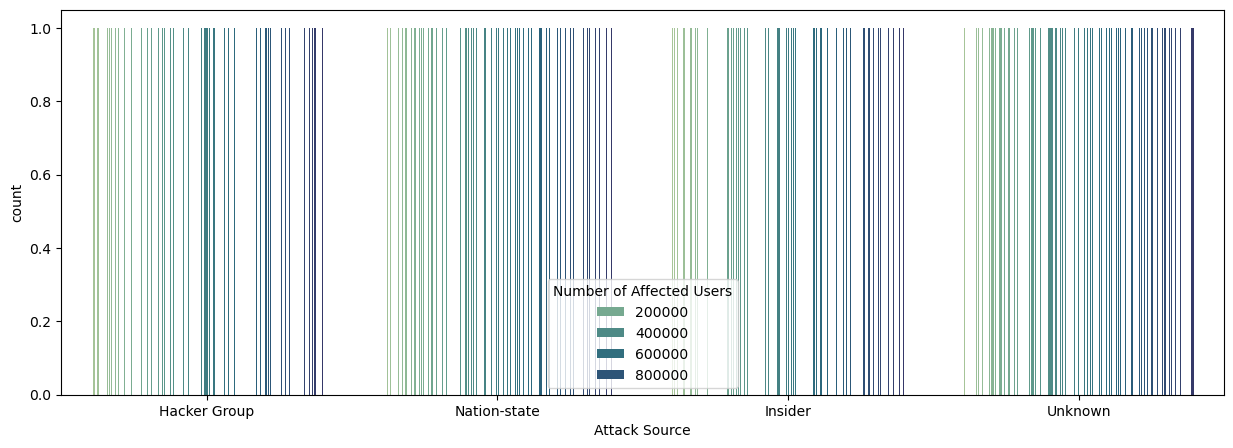

In [962]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Attack Source"],hue =cyber["Number of Affected Users"],palette="crest")

<Axes: xlabel='Security Vulnerability Type', ylabel='count'>

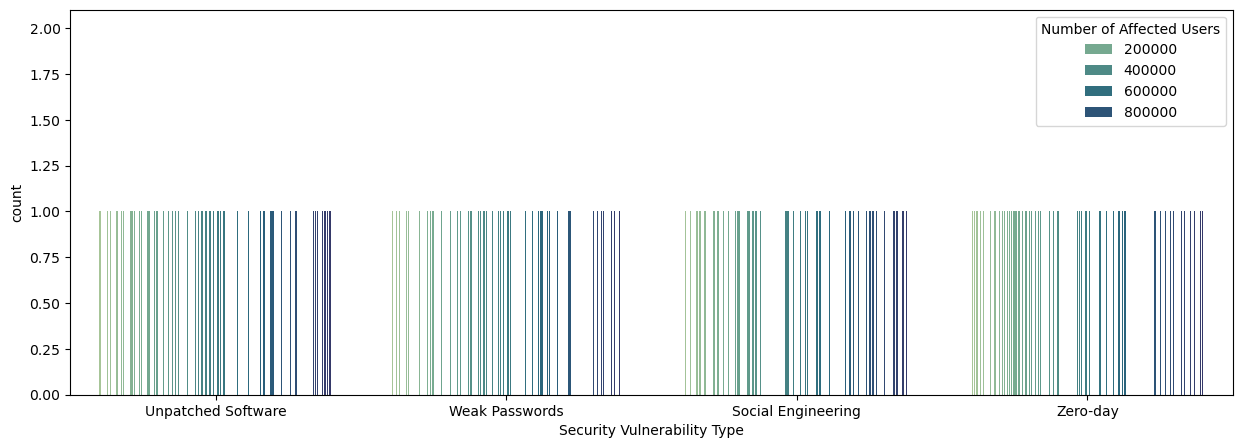

In [968]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Security Vulnerability Type"],hue =cyber["Number of Affected Users"],palette="crest")

<Axes: xlabel='Defense Mechanism Used', ylabel='count'>

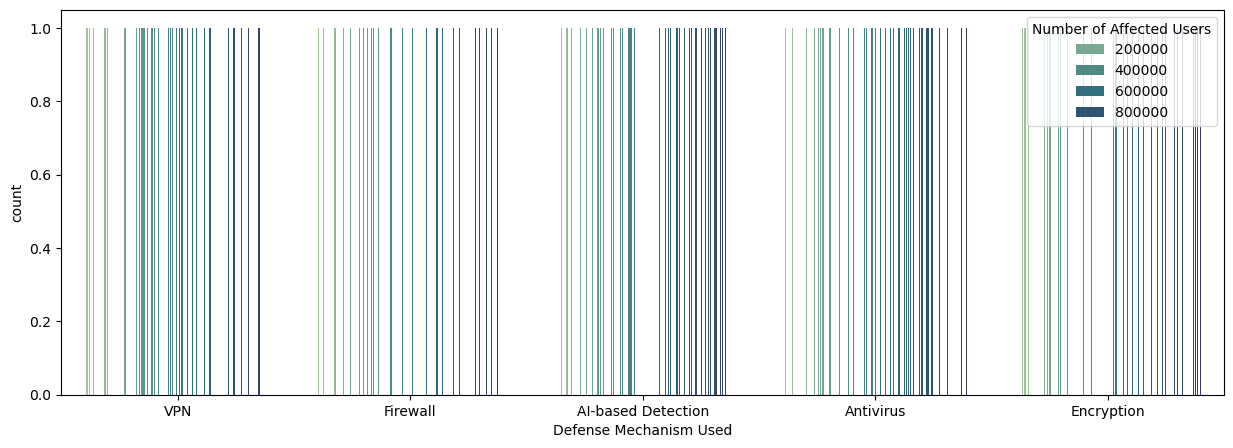

In [969]:
plt.rcParams["figure.figsize"] = (15,5)
sns.countplot(x=cyber["Defense Mechanism Used"],hue =cyber["Number of Affected Users"],palette="crest")

In [971]:
def cramers_V(var1,var2) :
  crosstab =np.array(pd.crosstab(var1,var2, rownames=None, colnames=None)) 
  stat = chi2_contingency(crosstab)[0] 
  obs = np.sum(crosstab) 
  mini = min(crosstab.shape)-1
  return np.sqrt((stat/(obs*mini)))

In [432]:
df1.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [434]:
cat_col=['Country', 'Year', 'Attack Type', 'Target Industry','Attack Source', 'Security Vulnerability Type','Defense Mechanism Used']

In [442]:
rows= []

for var1 in df1[cat_col]:
  col = []
  for var2 in df1[cat_col] :
    cramers =cramers_V(df1[var1], df1[var2])
    col.append(round(cramers,2))  
  rows.append(col)
  
cramers_results = np.array(rows)
df = pd.DataFrame(cramers_results, columns = df1[cat_col].columns, index = df1[cat_col].columns)

In [444]:
df

,Country,Year,Attack Type,Target Industry,Attack Source,Security Vulnerability Type,Defense Mechanism Used
Country,1.00,0.05,0.05,0.05,0.05,0.05,0.06
Year,0.05,1.00,0.05,0.05,0.05,0.05,0.05
Attack Type,0.05,0.05,1.00,0.05,0.03,0.05,0.04
Target Industry,0.05,0.05,0.05,1.00,0.06,0.04,0.05
Attack Source,0.05,0.05,0.03,0.06,1.00,0.03,0.04
Security Vulnerability Type,0.05,0.05,0.05,0.04,0.03,1.00,0.02
Defense Mechanism Used,0.06,0.05,0.04,0.05,0.04,0.02,1.00


<Axes: >

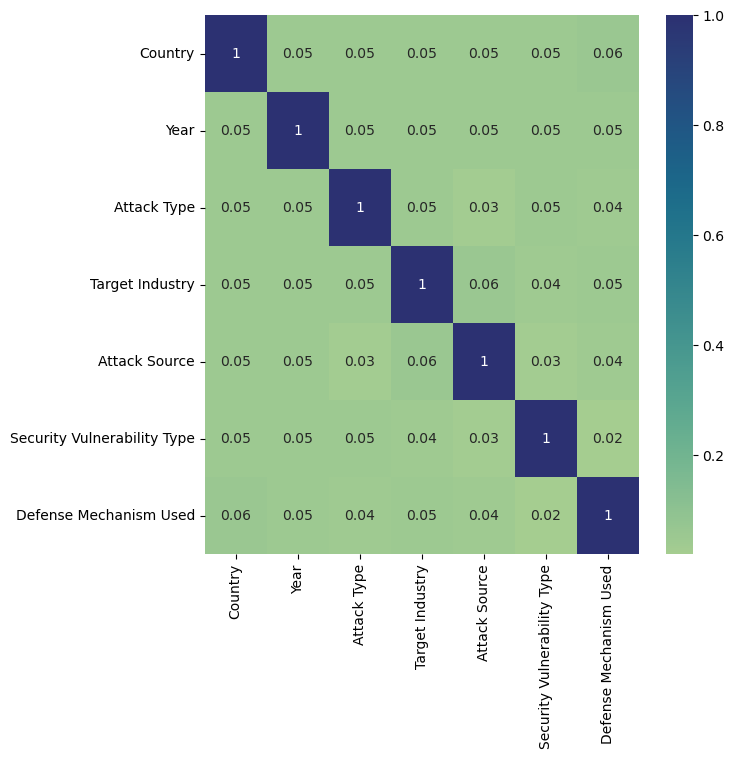

In [977]:
plt.rcParams["figure.figsize"] = (7,7)
sns.heatmap(df,cmap="crest", annot=True)

In [468]:
predictors = pd.get_dummies(df1, drop_first=True)

In [470]:
predictors.head(5)

,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours),Country_Brazil,Country_China,Country_France,Country_Germany,Country_India,Country_Japan,Country_Russia,...,Attack Source_Insider,Attack Source_Nation-state,Attack Source_Unknown,Security Vulnerability Type_Unpatched Software,Security Vulnerability Type_Weak Passwords,Security Vulnerability Type_Zero-day,Defense Mechanism Used_Antivirus,Defense Mechanism Used_Encryption,Defense Mechanism Used_Firewall,Defense Mechanism Used_VPN
0,80.53,773169,63,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,62.19,295961,71,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,38.65,605895,20,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
3,41.44,659320,7,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,74.41,810682,68,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True


In [474]:
predictors.shape

(3000, 42)

In [476]:
cyber_target = predictors [["Incident Resolution Time (in Hours)"]]

In [479]:
cyber_features = predictors.drop(columns="Incident Resolution Time (in Hours)")

In [485]:
cyber_features.shape

(3000, 41)

In [487]:
cyber_target.shape

(3000, 1)

In [489]:
x=cyber_features
y=cyber_target

In [587]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape , x_test.shape, y_train.shape, y_test.shape

((2400, 41), (600, 41), (2400, 1), (600, 1))

In [589]:
scaler = StandardScaler()

In [987]:
x_train_scaled = scaler.fit_transform(x_train)

In [989]:
x_test_scaled = scaler.transform(x_test)

In [991]:
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns = cyber_features.columns, index=x_train.index)

In [597]:
## PCA

In [993]:
pca = PCA(n_components = 'mle')
pca.fit(scaled_df)
x_pca = pca.transform(x_train_scaled_df)

In [995]:
x_pca.shape

(2400, 39)

In [997]:
pca.explained_variance_ratio_.sum()

0.9950145770078832

ValueError: 'c' argument has 3000 elements, which is inconsistent with 'x' and 'y' with size 2400.

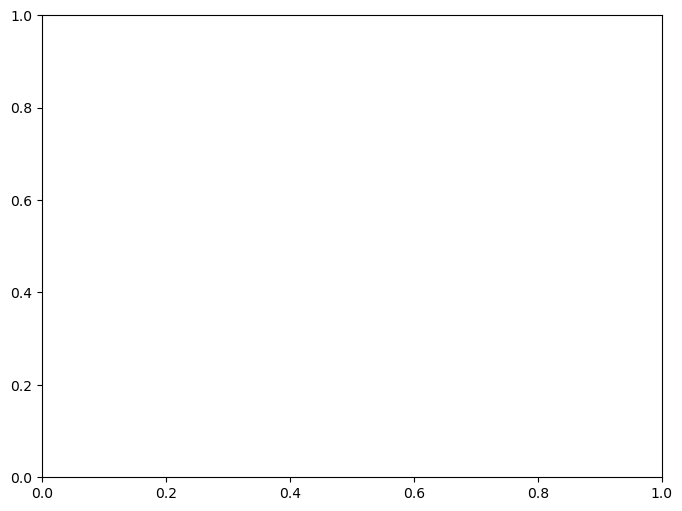

In [1033]:
plt.figure(figsize =(8, 6))
  
plt.scatter(x_pca[:, 0], x_pca[:, 1], c= predictors['Incident Resolution Time (in Hours)'], cmap ='crest')

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

In [1001]:
pca.components_

array([[ 1.08787020e-01,  5.99159245e-02,  1.27423216e-01, ...,
         1.56506292e-01, -8.96600357e-02, -1.82500250e-01],
       [ 3.73382249e-02,  6.29912436e-02,  1.32029368e-01, ...,
         3.34067335e-01,  1.23137556e-02, -9.22625870e-02],
       [ 9.32225187e-02,  2.35182113e-02,  3.73510287e-02, ...,
         9.63086778e-02, -1.97521404e-01, -9.01729101e-02],
       ...,
       [ 3.46388478e-04,  9.36199568e-04, -3.77179947e-03, ...,
        -4.82135340e-01, -4.84115832e-01, -4.85815979e-01],
       [-1.66880655e-02, -3.29209534e-03, -2.43896388e-02, ...,
         1.14416242e-01,  1.09553984e-01,  9.90731980e-02],
       [-4.26492804e-03,  1.00657098e-02, -1.15257096e-02, ...,
         1.70838259e-02,  1.77268128e-02,  4.68794787e-03]])

In [1003]:
import pandas as pd
df_x_pca = pd.DataFrame(x_pca)
df_x_pca.head()

,0,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,35,36,37,38
0,0.855471,0.816465,-0.934202,0.215764,-0.566742,-0.166892,0.179858,-0.363171,-1.091438,-1.321984,...,-0.487817,-0.949296,0.297954,-0.183987,1.351942,0.157096,0.949976,0.818821,-0.272843,-0.127597
1,-1.619803,-0.056184,0.182371,-0.943886,-0.180585,0.462617,1.742240,-1.091429,2.556985,0.567273,...,1.127941,0.562082,1.599490,1.421399,-0.224402,-0.531514,-0.018536,-0.191137,-0.154114,-0.190301
2,0.055332,-0.492085,1.789222,1.765185,1.029157,-0.036059,-0.887495,0.980394,0.257907,1.558631,...,0.363260,0.120256,1.858956,-0.617551,-0.627230,0.085471,1.084479,0.895141,-0.386296,-0.165769
3,0.278760,-0.522590,0.247156,1.378333,-0.928186,1.650226,-0.802891,-0.324699,0.998951,-0.505784,...,0.596215,-0.815519,0.922009,-0.324116,0.267166,1.407837,0.714685,0.851793,-0.298050,-0.150312
4,-0.366207,-0.968663,-2.484581,1.289167,0.367083,-0.610684,-1.390201,1.107874,-1.706392,0.021534,...,-0.949592,1.857469,-1.738363,0.016968,-0.839938,-0.400275,-0.032604,-0.393336,-0.125796,-0.192104


In [1005]:
scaled_df[0]

array([-0.59519283,  0.16402194, -0.33487441, -0.32556226, -0.3341044 ,
        3.0496605 , -0.35081295, -0.33641127, -0.32399441, -0.34175797,
       -0.33023825, -0.32790535,  2.91310247, -0.34175797, -0.31046907,
       -0.34931309, -0.33178797, -0.34251779, -0.33870879, -0.33101366,
       -0.43913886, -0.42008403, -0.46454867,  2.19022863, -0.44183608,
       -0.40277488, -0.39364538, -0.41250563,  2.27020839, -0.40137644,
       -0.39010813, -0.58312392, -0.60302269, -0.58440703, -0.56965192,
       -0.5728597 ,  1.66897842, -0.51298918, -0.50455324, -0.5       ,
       -0.50130175])

In [1007]:
(scaled_df[0]*pca.components_[0]).sum()

0.8554714016775129

In [1009]:
(scaled_df[0]*pca.components_[1]).sum()

0.8164647639171845

In [1011]:
(scaled_df[1]*pca.components_[0]).sum()

-1.6198029633815192

In [1013]:
cum_exp_var = []
s=0
for i in pca.explained_variance_ratio_:
    s+=i
    cum_exp_var.append(s)

Text(0, 0.5, 'Cumulative variance explained')

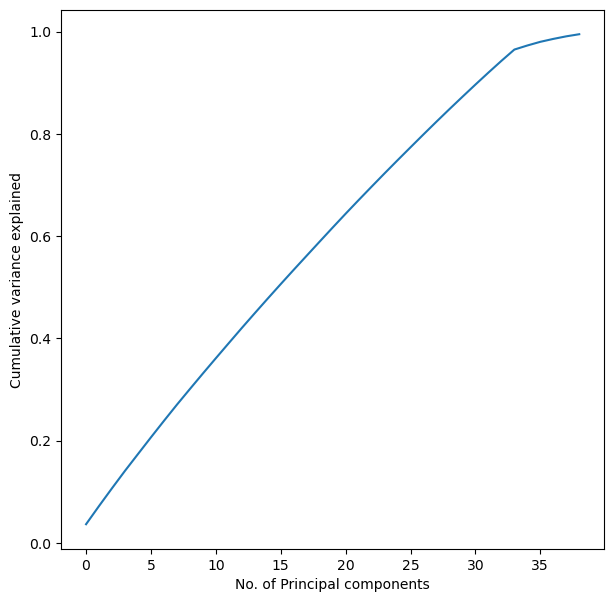

In [1025]:
plt.plot(range(39),cum_exp_var) 
plt.xlabel('No. of Principal components')
plt.ylabel('Cumulative variance explained')

In [658]:
pca.explained_variance_ratio_[:35].sum()

0.9651641580605372

In [693]:
pca = PCA(0.9)
principalComponents = pca.fit_transform(scaled_df)

In [697]:
cols = ["PC_" + str(i) for i in range(3000, 0)]
transformed_observations = pd.DataFrame(data = principalComponents, columns = cols)
transformed_observations['label'] = y
transformed_observations.head()

ValueError: Shape of passed values is (3000, 33), indices imply (3000, 0)

In [ ]:
#couldn't get code to work cause no matter how low the number was put it bugs.

In [ ]:
#Linear Regression

In [1017]:
x2 = sm.add_constant(x_train_scaled_df)

In [1019]:
lr= sm.OLS(y_train, x2).fit()

In [1021]:
#The F Statistic is High. This means the null value is accepted that there is no linear relationship here.

In [768]:
print(lr.summary())

                                     OLS Regression Results                                    
Dep. Variable:     Incident Resolution Time (in Hours)   R-squared:                       0.014
Model:                                             OLS   Adj. R-squared:                 -0.003
Method:                                  Least Squares   F-statistic:                    0.8322
Date:                                 Tue, 05 Aug 2025   Prob (F-statistic):              0.767
Time:                                         14:30:24   Log-Likelihood:                -10643.
No. Observations:                                 2400   AIC:                         2.137e+04
Df Residuals:                                     2358   BIC:                         2.161e+04
Df Model:                                           41                                         
Covariance Type:                             nonrobust                                         
                                        

In [770]:
x_test_df=pd.DataFrame(x_test_scaled, columns = cyber_features.columns, index=x_test.index)

In [772]:
xtest2 = sm.add_constant(x_test_df, has_constant="add")

In [774]:
y_pred = lr.predict(xtest2)

In [776]:
y_pred[:5]

1801    36.094340
1190    38.068570
1817    36.069858
251     32.954780
2505    35.837539
dtype: float64

Text(0, 0.5, 'y_pred')

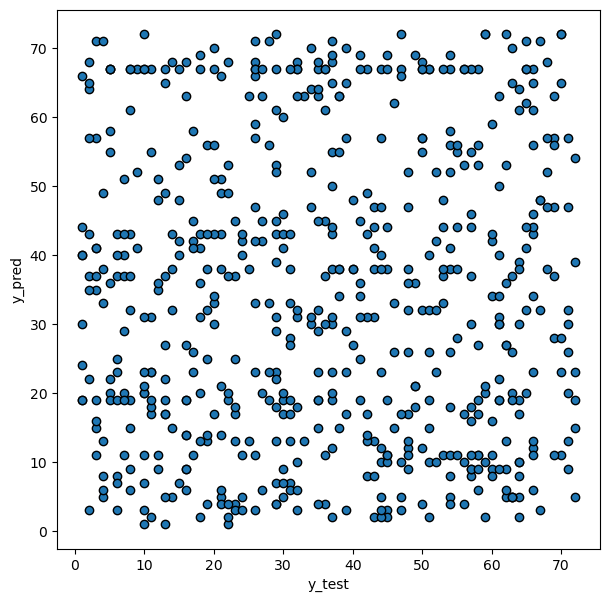

In [1023]:
y_pred = model.predict(x_test)


plt.scatter(y_test, y_pred, edgecolor='black')
plt.xlabel("y_test")
plt.ylabel("y_pred")

In [778]:
r2_testset = r2_score(y_test, y_pred)
print("r2 score on test data:", r2_testset)

r2 score on test data: -0.03680053932784322


In [780]:
adj_r2_testset = 1 - ((1-r2_testset)*(xtest2.shape[0]-1)/ (xtest2.shape[0]-xtest2.shape[1]-1))
print ("adjusted r2 score for test data:", adj_r2_testset)

adjusted r2 score for test data: -0.1149793950760829


In [730]:
maxp = lr.pvalues.max()
while(maxp>0.05):
    print(f"Adjusted R-Squared is {lr.rsquared_adj}")
    print(f"{lr.pvalues.idxmax()} with p-value of {maxp} was dropped \n")
    x2.drop(lr.pvalues.idxmax(), axis=1, inplace=True)
    ols = sm.OLS(y_train,x2)
    lr=ols.fit()
    maxp=lr.pvalues.max()
print(lr.summary())

Adjusted R-Squared is -0.0028753087694572965
Country_UK with p-value of 0.8862160733969161 was dropped 

Adjusted R-Squared is -0.0024588881909450855
Country_France with p-value of 0.9214219136857765 was dropped 

Adjusted R-Squared is -0.0020382515471935037
Defense Mechanism Used_Antivirus with p-value of 0.8422318523426842 was dropped 

Adjusted R-Squared is -0.0016306564440229376
Attack Type_Ransomware with p-value of 0.722779800512006 was dropped 

Adjusted R-Squared is -0.0012599745712902344
Attack Type_Phishing with p-value of 0.7370677848268166 was dropped 

Adjusted R-Squared is -0.0008840241833221185
Attack Type_SQL Injection with p-value of 0.7534069475353223 was dropped 

Adjusted R-Squared is -0.0005024321989062219
Attack Source_Insider with p-value of 0.6911454988888412 was dropped 

Adjusted R-Squared is -0.00014618004381250493
Attack Source_Nation-state with p-value of 0.7052727012047657 was dropped 

Adjusted R-Squared is 0.00021605408839087126
Number of Affected Users 

In [ ]:
#I honestly don't know what a NAN f-statistic Means.

In [ ]:
#It looks like every single column except the constant was dropped by that.

In [760]:
#I am rereunning the previous cells up till the drop, and then what's after.

In [782]:
r2_testset = r2_score (y_test, y_pred)
print ("R2 score for test set is: ", r2_testset)
adj_r2_testset = 1 - ((1-r2_testset)*(xtest2.shape[0]-1)/(xtest2.shape[0]-xtest2.shape[1]-1))
print("Ajusted R2 score for test set is: ", adj_r2_testset)

R2 score for test set is:  -0.03680053932784322
Ajusted R2 score for test set is:  -0.1149793950760829


In [784]:
scores = cross_val_score(LinearRegression(), x2, y_train, cv=5)
scores

array([-0.01258786, -0.0270845 , -0.00863455, -0.01648424, -0.02933221])

In [786]:
scores.mean()

-0.01882467073925076

In [788]:
cv = KFold(n_splits=5, random_state=42, shuffle=True)
model= LinearRegression()
scores2 = cross_val_score(model, x2, y_train, scoring='explained_variance', cv=cv, n_jobs=-1)
scores2.mean()

-0.02932947717904697

In [789]:
cv=KFold(n_splits=5, random_state=42, shuffle=True)
model=LinearRegression()
scores3=cross_val_score(model, x2, y_train, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
np.sqrt(np.mean(abs(scores3)))

20.84807983363094

In [797]:
cyber.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [808]:
cyber.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


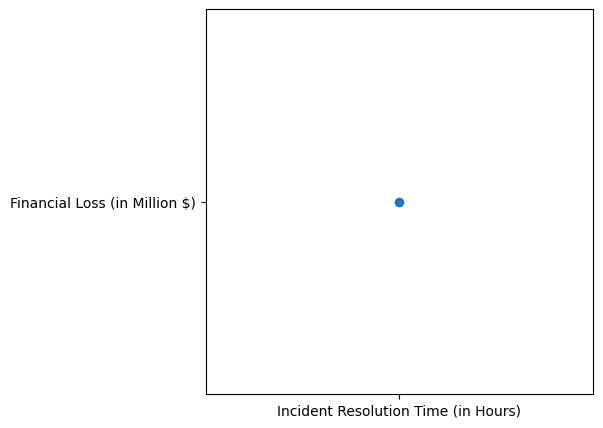

In [820]:
plt.scatter(['Incident Resolution Time (in Hours)'], ['Financial Loss (in Million $)'], data=cyber)
plt.show()

In [ ]:
#Generally maybe this data set is just not good for LR.

In [830]:
model = DecisionTreeRegressor(random_state=42)

In [834]:
kfold_score=cross_val_score(model, x_train, y_train, cv=5).mean()

In [840]:
model.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

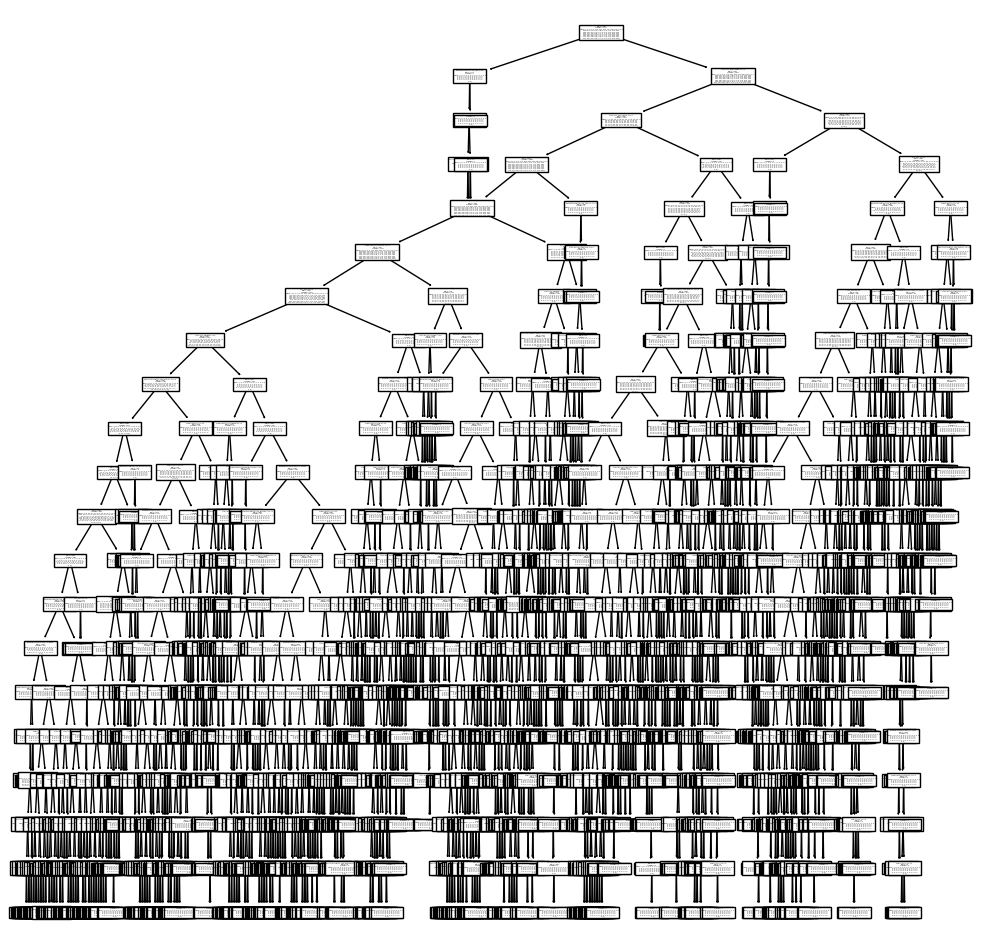

In [980]:
plt.figure(figsize = (12,12))
plot_tree(model, feature_names=x.columns)
plt.savefig('STUPIDTREE.png')

In [849]:
train_accuracy = model.score(x_train,y_train)
print('Decision Tree accuracy on Train data', train_accuracy)

Decision Tree accuracy on Train data 1.0


In [851]:
test_accuracy=model.score(x_test,y_test)
print('Decision Tree accuracy on Test data', test_accuracy)

Decision Tree accuracy on Test data -1.0584521481533642


In [1027]:
train_scores = []
test_scores = []
for depth in range(1,21):
    model = DecisionTreeRegressor(max_depth = depth)
    model.fit(x_train,y_train)
    train_accuracy = model.score(x_train,y_train)
    train_scores.append(train_accuracy)
    test_accuracy = model.score(x_test,y_test)
    test_scores.append(test_accuracy)
    print(f'Model max_depth = {depth},train_score={train_accuracy},test_score={test_accuracy}')

Model max_depth = 1,train_score=0.0014808194940995056,test_score=-0.00524112659357634
Model max_depth = 2,train_score=0.0074020250733498605,test_score=-0.01124980174553114
Model max_depth = 3,train_score=0.014154488906903961,test_score=-0.04115126727410923
Model max_depth = 4,train_score=0.02284233142732872,test_score=-0.062199124819228846
Model max_depth = 5,train_score=0.03188506401205138,test_score=-0.05783299502325967
Model max_depth = 6,train_score=0.04133235767571786,test_score=-0.07329337141455139
Model max_depth = 7,train_score=0.058075678576140266,test_score=-0.09324592322209235
Model max_depth = 8,train_score=0.07886241250924908,test_score=-0.08814758158469704
Model max_depth = 9,train_score=0.10936229239732675,test_score=-0.14217773772409004
Model max_depth = 10,train_score=0.1402910503606971,test_score=-0.1851035151010607
Model max_depth = 11,train_score=0.18042451174477991,test_score=-0.20525463486814055
Model max_depth = 12,train_score=0.22891313137231295,test_score=-0.23

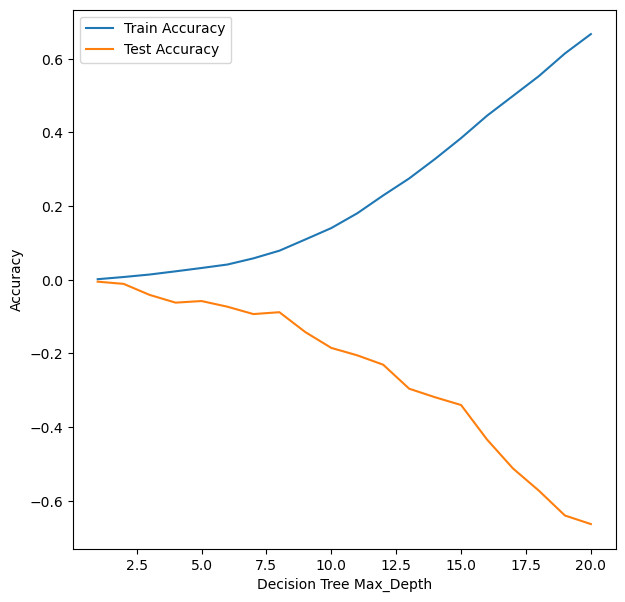

In [1029]:
plt.plot(range(1,21), train_scores, label = "Train Accuracy")
plt.plot(range(1,21),test_scores, label = "Test Accuracy")
plt.xlabel("Decision Tree Max_Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
#It just does terribly on the test data no matter what you do.

In [860]:
knn= KNeighborsRegressor()

In [862]:
knn.fit(x_train_scaled, y_train)

KNeighborsRegressor()

In [864]:
print("KNN Model(basic) accuracy on test data: ", knn.score(x_test_scaled,y_test))

KNN Model(basic) accuracy on test data:  -0.21096710055653123


In [ ]:
#This is also terrible.